# Start

In [1]:
import pandas as pd
# import seaborn as sns
from scipy.stats import norm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, QuantileTransformer,RobustScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-paper')
# plt.rc('font', family='serif', size=10)
# plt.rc('text', usetex=True)
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score, explained_variance_score

In [198]:
!pip install xgboost

  Using cached xgboost-2.1.3-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nccl_cu12-2.25.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.8 kB)
Using cached xgboost-2.1.3-py3-none-manylinux_2_28_x86_64.whl (153.9 MB)
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/201.4 MB 403.6 kB/s eta 0:08:13
ERROR: Exception:
Traceback (most recent call last):
  File "/home/baco/codespace/LabSolar/jacasolarenv/lib/python3.10/site-packages/pip/_vendor/urllib3/response.py", line 438, in _error_catcher
    yield
  File "/home/baco/codespace/LabSolar/jacasolarenv/lib/python3.10/site-packages/pip/_vendor/urllib3/response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
  File "/home/baco/codespace/LabSolar/jacasolarenv/lib/python3.10/site-packages/pip/_vendor/urllib3/response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
  File "/home/baco/codespace/LabSolar/jacasolarenv/li

In [ ]:
print(plt.style.available)

## Functions

In [75]:
def calcular_metricas(y_test, y_pred):
    return {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred),
        'EVS': explained_variance_score(y_test, y_pred),
    }
'''
outliers_by_hour = {}
df_cleaned = df.copy()  # Fazendo uma cópia do DataFrame para evitar modificar o original
df.drop(columns=['hour'], inplace = True)
for hour in range(24):
    hour_data = df_cleaned[df_cleaned['hour'] == hour]['RADIACAO GLOBAL(Kj/m²)']
    Q1 = hour_data.quantile(0.25)
    Q3 = hour_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = hour_data[(hour_data < lower) | (hour_data > upper)]
    outliers_by_hour[hour] = outliers
    df_cleaned = df_cleaned[~df_cleaned.index.isin(outliers.index)]
    
# for hour, outliers in outliers_by_hour.items():
#     print(f"Outliers para a hora {hour}: {len(outliers)} outliers encontrados.")
df_cleaned.drop(columns=['hour'], inplace = True)
print(f"Linhas restantes após remoção de outliers: {len(df_cleaned)}")
'''

'\noutliers_by_hour = {}\ndf_cleaned = df.copy()  # Fazendo uma cópia do DataFrame para evitar modificar o original\ndf.drop(columns=[\'hour\'], inplace = True)\nfor hour in range(24):\n    hour_data = df_cleaned[df_cleaned[\'hour\'] == hour][\'RADIACAO GLOBAL(Kj/m²)\']\n    Q1 = hour_data.quantile(0.25)\n    Q3 = hour_data.quantile(0.75)\n    IQR = Q3 - Q1\n    lower = Q1 - 1.5 * IQR\n    upper = Q3 + 1.5 * IQR\n    outliers = hour_data[(hour_data < lower) | (hour_data > upper)]\n    outliers_by_hour[hour] = outliers\n    df_cleaned = df_cleaned[~df_cleaned.index.isin(outliers.index)]\n    \n# for hour, outliers in outliers_by_hour.items():\n#     print(f"Outliers para a hora {hour}: {len(outliers)} outliers encontrados.")\ndf_cleaned.drop(columns=[\'hour\'], inplace = True)\nprint(f"Linhas restantes após remoção de outliers: {len(df_cleaned)}")\n'

## DATA(Load and preprocessing)

In [7]:
# path = "Dados_da_Região_Norte/dados_A215_H_2008-06-13_2024-01-01.csv"
path = "Dados da Região Norte/dados_A215_H_2008-06-13_2024-01-01.csv"

df = pd.read_csv(path, header = 9, sep =';')
df.drop(columns= ['Unnamed: 22'], axis =1,inplace = True)
df.replace(to_replace = ',', value = '.', regex = True, inplace =True)
df = df.apply(pd.to_numeric, errors = 'ignore')
df['Hora Medicao'] = df['Hora Medicao']/100
df['Hora Medicao'] = df['Hora Medicao'].astype(int).astype(str).str.zfill(2)
df['Hora Medicao'] = pd.to_datetime(df['Hora Medicao'], format='%H').dt.time
df['Data_Hora'] = pd.to_datetime(df['Data Medicao'] +' '+ df['Hora Medicao'].astype(str))
df.set_index('Data_Hora', inplace= True)
df.dropna(inplace = True)
df['hour']= df.index.hour
# df = df[(df.index.hour >= 12) & (df.index.hour <=20)]
df.drop(columns=['Data Medicao', 'Hora Medicao', 'hour'], inplace = True)
df.sort_index(inplace =True)
df['SMA_5'] = df['RADIACAO GLOBAL(Kj/m²)'].rolling(window=5,center =True).mean()
df['VEL_VENTO_km_h'] = df['VENTO, VELOCIDADE HORARIA(m/s)'] * 3.6
df['ST'] = 33 + (10 * np.sqrt(df['VEL_VENTO_km_h']) + 10.45 - df['VEL_VENTO_km_h']) * (df['TEMPERATURA DO AR - BULBO SECO, HORARIA(°C)'] - 33) / 22
df.dropna(inplace =True)
df.drop(columns=['ST', 'SMA_5', 'VEL_VENTO_km_h'], inplace = True)

columns_translation = {
    'PRECIPITACAO TOTAL, HORARIO(mm)': 'TOTAL PRECIPITATION, HOURLY (mm)',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA(mB)': 'ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)',
    'PRESSAO ATMOSFERICA REDUZIDA NIVEL DO MAR, AUT(mB)': 'ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT (mB)',
    'PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT)(mB)': 'ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB)',
    'PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT)(mB)': 'ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB)',
    'RADIACAO GLOBAL(Kj/m²)': 'GLOBAL RADIATION (Kj/m²)',
    'TEMPERATURA DA CPU DA ESTACAO(°C)': 'STATION CPU TEMPERATURE (°C)',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA(°C)': 'AIR TEMPERATURE - DRY BULB, HOURLY (°C)',
    'TEMPERATURA DO PONTO DE ORVALHO(°C)': 'DEW POINT TEMPERATURE (°C)',
    'TEMPERATURA MAXIMA NA HORA ANT. (AUT)(°C)': 'MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA MINIMA NA HORA ANT. (AUT)(°C)': 'MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT)(°C)': 'MAXIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT)(°C)': 'MINIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TENSAO DA BATERIA DA ESTACAO(V)': 'STATION BATTERY VOLTAGE (V)',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT)(%)': 'RELATIVE HUMIDITY MAX. IN THE PREVIOUS HOUR (AUT) (%)',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT)(%)': 'RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%)',
    'UMIDADE RELATIVA DO AR, HORARIA(%)': 'AIR RELATIVE HUMIDITY, HOURLY (%)',
    'VENTO, DIRECAO HORARIA (gr)(° (gr))': 'WIND, HOURLY DIRECTION (gr) (° (gr))',
    'VENTO, RAJADA MAXIMA(m/s)': 'WIND, MAXIMUM GUST (m/s)',
    'VENTO, VELOCIDADE HORARIA(m/s)': 'WIND, HOURLY SPEED (m/s)'
}
df.rename(columns=columns_translation, inplace=True)
df.to_parquet('FormatDataSalinas.gzip', compression = 'gzip')

# df.fillna(method= 'ffill')

# Loading Data

In [4]:
!pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 3.7 MB/s eta 0:00:00m eta 0:00:010:00:01


In [29]:
df = pd.read_parquet('FormatDataSalinas.gzip')

In [165]:
# df.drop(columns=['ST', 'SMA_5', 'VEL_VENTO_km_h'], inplace = True)

In [4]:
# df = df[(df.index.hour >= 10) & (df.index.hour <=22)]

## Database Division

In [7]:
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')
print(f'Tamanho da Base de dados: {len(X)}')

size = 0.8
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

Tamanho da Base de dados: 88339
Tamanho da base de treino: 0.8
Treino: 70671, Teste: 17668


In [5]:
'''columns_translation = {
    'PRECIPITACAO TOTAL, HORARIO(mm)': 'TOTAL PRECIPITATION, HOURLY (mm)',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA(mB)': 'ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)',
    'PRESSAO ATMOSFERICA REDUZIDA NIVEL DO MAR, AUT(mB)': 'ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT (mB)',
    'PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT)(mB)': 'ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB)',
    'PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT)(mB)': 'ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB)',
    'RADIACAO GLOBAL(Kj/m²)': 'GLOBAL RADIATION (Kj/m²)',
    'TEMPERATURA DA CPU DA ESTACAO(°C)': 'STATION CPU TEMPERATURE (°C)',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA(°C)': 'AIR TEMPERATURE - DRY BULB, HOURLY (°C)',
    'TEMPERATURA DO PONTO DE ORVALHO(°C)': 'DEW POINT TEMPERATURE (°C)',
    'TEMPERATURA MAXIMA NA HORA ANT. (AUT)(°C)': 'MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA MINIMA NA HORA ANT. (AUT)(°C)': 'MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT)(°C)': 'MAXIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT)(°C)': 'MINIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TENSAO DA BATERIA DA ESTACAO(V)': 'STATION BATTERY VOLTAGE (V)',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT)(%)': 'RELATIVE HUMIDITY MAX. IN THE PREVIOUS HOUR (AUT) (%)',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT)(%)': 'RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%)',
    'UMIDADE RELATIVA DO AR, HORARIA(%)': 'AIR RELATIVE HUMIDITY, HOURLY (%)',
    'VENTO, DIRECAO HORARIA (gr)(° (gr))': 'WIND, HOURLY DIRECTION (gr) (° (gr))',
    'VENTO, RAJADA MAXIMA(m/s)': 'WIND, MAXIMUM GUST (m/s)',
    'VENTO, VELOCIDADE HORARIA(m/s)': 'WIND, HOURLY SPEED (m/s)'
}

df.rename(columns=columns_translation, inplace=True)'''

# Modelos Simples

## Sem corte nas horas

### Sem escalar os dados

In [49]:
models = {'RandForest':RandomForestRegressor(n_jobs = -1),'XGB':XGBRegressor(n_jobs = -1),'SVR':SVR(kernel ='rbf'),'KNN':KNeighborsRegressor(n_jobs= -1)}
keys = ['RandForest', 'XGB', 'SVR', 'KNN']

scalers = {'Standard':StandardScaler(),'MinMax':MinMaxScaler(),'Quantile':QuantileTransformer(),'Robust':RobustScaler()}
scalersKeys=['Standard', 'MinMax', 'Quantile', 'Robust']

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(16,8))
tempdf = y_train.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdf.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdf['hour'] = tempdf['Data_Hora'].dt.hour
tempdf.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[0,0])
ax[0,0].set_xlabel('Hour')
ax[0,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[0,1].hist(tempdf['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[0,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[0,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[0,1].legend()
tempdftest = y_test.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdftest.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdftest['hour'] = tempdftest['Data_Hora'].dt.hour
tempdftest.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[1,0])
ax[1,0].set_xlabel('Hour')
ax[1,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[1,1].hist(tempdftest['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[1,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
# df.drop(columns=['hour'],inplace=True)
ax[1,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[1,1].legend()
plt.tight_layout()
plt.show()

In [171]:
metricas_calculadas = []
predicts = []
for j in range(len(models)):
    key = keys[j]
    model = models[key]
    model.fit(X_train,y_train)
    print(f'Modelo ({key}) treinado!')
    predict = model.predict(X_test)
    model_pred = {'Modelo':key, 'Predicoes':predict}
    predicts.append(model_pred)
    metricas = {'Modelo': key, 'Metricas': calcular_metricas(y_test, predict)}
    metricas_calculadas.append(metricas)

Modelo (RandForest) treinado!
Modelo (XGB) treinado!
Modelo (SVR) treinado!
Modelo (KNN) treinado!


In [172]:
print(metricas_calculadas)

[{'Modelo': 'RandForest', 'Metricas': {'MSE': 144599.7871795303, 'RMSE': 380.2627870033174, 'MAE': 235.17932031356125, 'MAPE': 5128378487647.595, 'R²': 0.8275338328691562, 'EVS': 0.8285895304122346}}, {'Modelo': 'XGB', 'Metricas': {'MSE': 138254.51006023478, 'RMSE': 371.8259136480872, 'MAE': 223.34107777391, 'MAPE': 11592828508262.178, 'R²': 0.8351019326948443, 'EVS': 0.8384754849732214}}, {'Modelo': 'SVR', 'Metricas': {'MSE': 1258164.354829519, 'RMSE': 1121.6792566636502, 'MAE': 680.8860359769989, 'MAPE': 5305499858288.965, 'R²': -0.5006300363961773, 'EVS': 0.008207166821306289}}, {'Modelo': 'KNN', 'Metricas': {'MSE': 170771.34950137854, 'RMSE': 413.24490257156054, 'MAE': 237.6199633688024, 'MAPE': 276109300252.553, 'R²': 0.796318648327625, 'EVS': 0.8087112772471456}}]


### Escalando os Dados

In [180]:
pred_allScaledModels = []
metrics_allScaledModels = []
for k in scalersKeys:
    scaler = scalers[k]
    print(scaler)
    scaler_x = scaler
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled  = scaler_x.fit_transform(X_test)
    scaler_y = scaler
    y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
    print(X_train_scaled.shape, y_train_scaled.shape, X_test_scaled.shape)    
    for m in keys:
        model = models[m]
        print(m)
        model.fit(X_train_scaled, y_train_scaled)
        predict = model.predict(X_test_scaled)
        predict = scaler_y.inverse_transform(predict.reshape(-1,1)).ravel()
        predict_dic = {'Model':m,'Scaler':k,'estimation':predict}
        pred_allScaledModels.append(predict_dic)
        metrics = calcular_metricas(y_test, predict)
        metrics_dic = {'Model':m,'Scaler':k,'metrics':metrics}
        metrics_allScaledModels.append(metrics_dic)     

StandardScaler()
(70671, 19) (70671,) (17668, 19)
RandForest
XGB
SVR
KNN
MinMaxScaler()
(70671, 19) (70671,) (17668, 19)
RandForest
XGB
SVR
KNN
QuantileTransformer()
(70671, 19) (70671,) (17668, 19)
RandForest
XGB
SVR
KNN
RobustScaler()
(70671, 19) (70671,) (17668, 19)
RandForest
XGB
SVR
KNN


In [181]:
print(metrics_allScaledModels)

[{'Model': 'RandForest', 'Scaler': 'Standard', 'metrics': {'MSE': 254759.9726812881, 'RMSE': 504.7375285049529, 'MAE': 389.61531928797837, 'MAPE': 125713313802739.34, 'R²': 0.6961442552322092, 'EVS': 0.7631933296093818}}, {'Model': 'XGB', 'Scaler': 'Standard', 'metrics': {'MSE': 214300.5042628532, 'RMSE': 462.9260246117658, 'MAE': 347.8441827154212, 'MAPE': 70508065643475.55, 'R²': 0.7444008230901921, 'EVS': 0.7805876749700511}}, {'Model': 'SVR', 'Scaler': 'Standard', 'metrics': {'MSE': 178008.35635912593, 'RMSE': 421.9103653136836, 'MAE': 311.1975886011785, 'MAPE': 81380572842886.53, 'R²': 0.7876869701031912, 'EVS': 0.8129963051828845}}, {'Model': 'KNN', 'Scaler': 'Standard', 'metrics': {'MSE': 220995.57851124837, 'RMSE': 470.10166827107554, 'MAE': 295.9960708852162, 'MAPE': 36766278026575.0, 'R²': 0.7364155153881584, 'EVS': 0.7448351175552843}}, {'Model': 'RandForest', 'Scaler': 'MinMax', 'metrics': {'MSE': 226848.70381935558, 'RMSE': 476.286367450671, 'MAE': 339.59848925401855, 'MAP

## Corte nas horas 

In [25]:
df = pd.read_parquet('FormatDataSalinas.gzip')

In [27]:
df = df[(df.index.hour >= 11) & (df.index.hour <=21)]

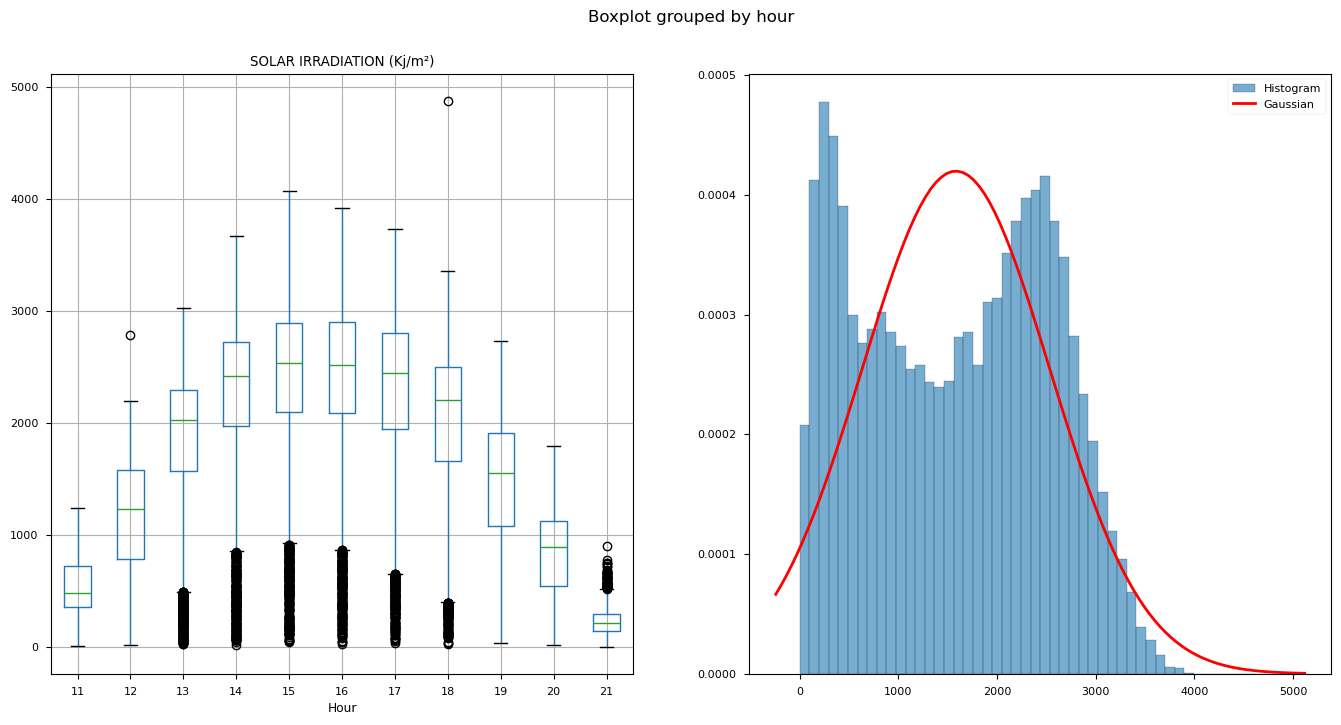

In [29]:
df['hour']= df.index.hour
fig, ax = plt.subplots(1,2,figsize=(16,8))
df.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[0])
ax[0].set_xlabel('Hour')
ax[0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[1].hist(df['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
df.drop(columns=['hour'],inplace=True)
ax[1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[1].legend()
plt.show()

In [31]:
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = ['GLOBAL RADIATION (Kj/m²)'])
size = 0.8
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

Tamanho da base de treino: 0.8
Treino: 32630, Teste: 8158


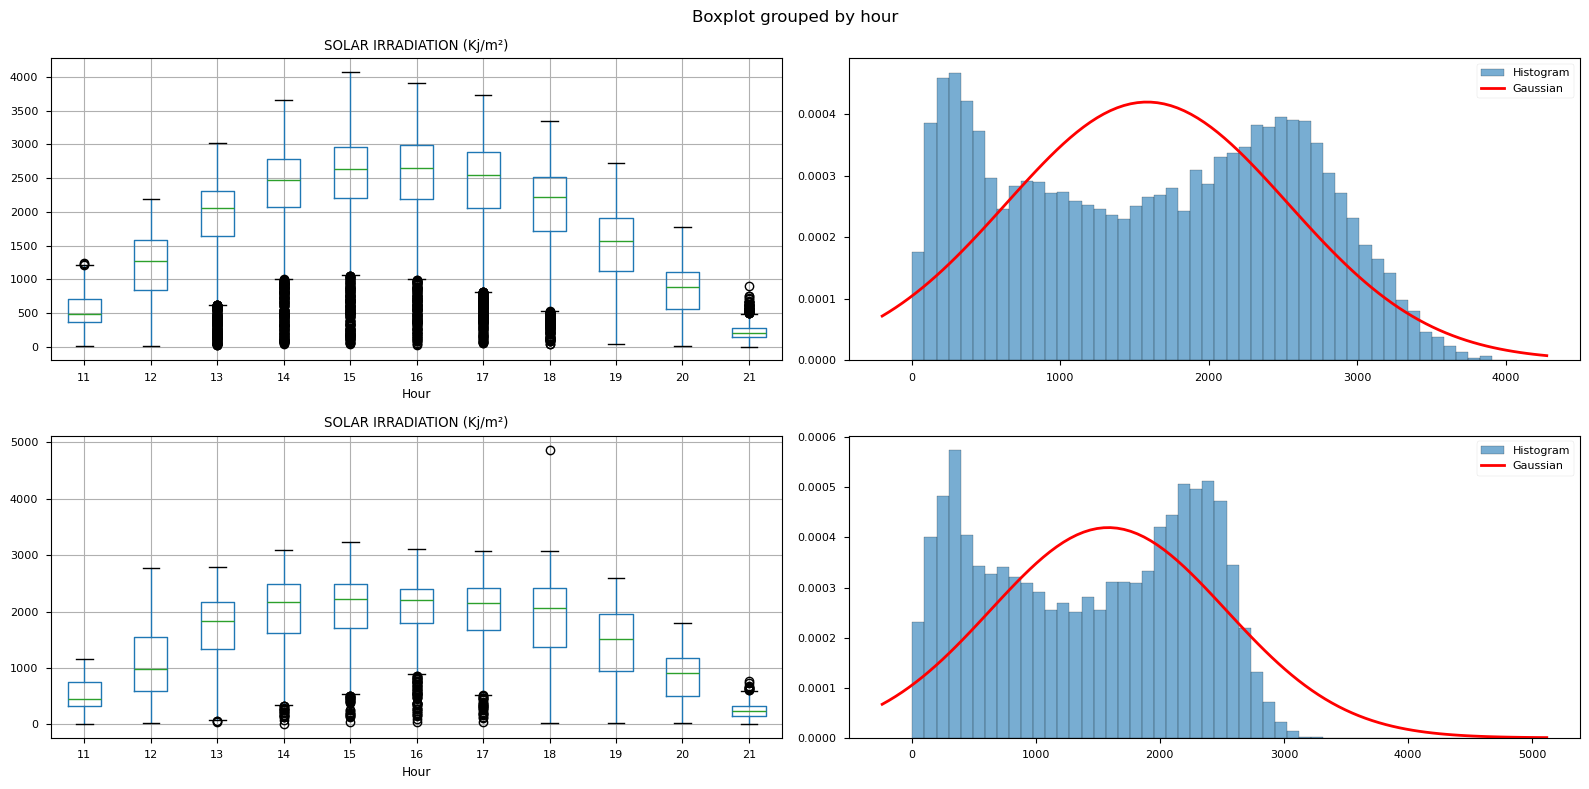

In [33]:
fig, ax = plt.subplots(2,2,figsize=(16,8))
tempdf = y_train.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdf.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdf['hour'] = tempdf['Data_Hora'].dt.hour
tempdf.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[0,0])
ax[0,0].set_xlabel('Hour')
ax[0,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[0,1].hist(tempdf['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[0,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[0,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[0,1].legend()
tempdftest = y_test.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdftest.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdftest['hour'] = tempdftest['Data_Hora'].dt.hour
tempdftest.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[1,0])
ax[1,0].set_xlabel('Hour')
ax[1,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[1,1].hist(tempdftest['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[1,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
# df.drop(columns=['hour'],inplace=True)
ax[1,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[1,1].legend()
plt.tight_layout()
plt.show()

### Sem escalador

In [35]:
metricas_calculadas_hourcrop = []
predicts_hourcrop = []
for j in range(len(models)):
    key = keys[j]
    model = models[key]
    model.fit(X_train,y_train)
    print(f'Modelo ({key}) treinado!')
    predict = model.predict(X_test)
    model_pred = {'Modelo':key, 'Predicoes':predict}
    predicts_hourcrop.append(model_pred)
    metricas = {'Modelo': key, 'Metricas': calcular_metricas(y_test, predict)}
    metricas_calculadas_hourcrop.append(metricas)

Modelo (RandForest) treinado!
Modelo (XGB) treinado!
Modelo (SVR) treinado!
Modelo (KNN) treinado!


In [36]:
print(metricas_calculadas_hourcrop)

[{'Modelo': 'RandForest', 'Metricas': {'MSE': 252309.02838355605, 'RMSE': 502.30372125194936, 'MAE': 376.2120976489335, 'MAPE': 0.5440808632279243, 'R²': 0.6413583724436412, 'EVS': 0.6632860083015243}}, {'Modelo': 'XGB', 'Metricas': {'MSE': 226028.42982977175, 'RMSE': 475.4244733180779, 'MAE': 358.3908728806034, 'MAPE': 0.4826768079983624, 'R²': 0.6787146125229946, 'EVS': 0.6997916546533038}}, {'Modelo': 'SVR', 'Metricas': {'MSE': 762563.8752549279, 'RMSE': 873.24903392728, 'MAE': 753.3950766242315, 'MAPE': 2.1977665930843333, 'R²': -0.0839372300279353, 'EVS': 0.005895895550908303}}, {'Modelo': 'KNN', 'Metricas': {'MSE': 261722.7756911397, 'RMSE': 511.58848275849573, 'MAE': 383.46522682029905, 'MAPE': 0.5380702968645388, 'R²': 0.6279773147881709, 'EVS': 0.6424547068159895}}]


### Escaladores e modelos

In [37]:
pred_allScaledModelsHourCrop = []
metrics_allScaledModelsHourCrop = []
for k in scalersKeys:
    scaler = scalers[k]
    print(scaler)
    scaler_x = scaler
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled  = scaler_x.fit_transform(X_test)
    scaler_y = scaler
    y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
    print(X_train_scaled.shape, y_train_scaled.shape, X_test_scaled.shape)    
    for m in keys:
        model = models[m]
        print(m)
        model.fit(X_train_scaled, y_train_scaled)
        predict = model.predict(X_test_scaled)
        predict = scaler_y.inverse_transform(predict.reshape(-1,1)).ravel()
        predict_dic = {'Model':m,'Scaler':k,'estimation':predict}
        pred_allScaledModelsHourCrop.append(predict_dic)
        metrics_dic = {'Model':m,'Scaler':k,'metrics': calcular_metricas(y_test, predict)}
        metrics_allScaledModelsHourCrop.append(metrics_dic)     

StandardScaler()
(32630, 19) (32630,) (8158, 19)
RandForest
XGB
SVR
KNN
MinMaxScaler()
(32630, 19) (32630,) (8158, 19)
RandForest
XGB
SVR
KNN
QuantileTransformer()
(32630, 19) (32630,) (8158, 19)
RandForest
XGB
SVR
KNN
RobustScaler()
(32630, 19) (32630,) (8158, 19)
RandForest
XGB
SVR
KNN


In [41]:
print(metrics_allScaledModelsHourCrop)

[{'Model': 'RandForest', 'Scaler': 'Standard', 'metrics': {'MSE': 348730.7519257003, 'RMSE': 590.5342936068153, 'MAE': 472.49541202745775, 'MAPE': 0.8151957552628819, 'R²': 0.5043008755934903, 'EVS': 0.5726440417887877}}, {'Model': 'XGB', 'Scaler': 'Standard', 'metrics': {'MSE': 307954.6685062916, 'RMSE': 554.9366346766914, 'MAE': 439.45091787737283, 'MAPE': 0.6560115521629838, 'R²': 0.5622615479348677, 'EVS': 0.5977226305735936}}, {'Model': 'SVR', 'Scaler': 'Standard', 'metrics': {'MSE': 265657.97383438266, 'RMSE': 515.4201915276337, 'MAE': 414.0009927082706, 'MAPE': 0.5873418601243975, 'R²': 0.6223836748146383, 'EVS': 0.6803417864458305}}, {'Model': 'KNN', 'Scaler': 'Standard', 'metrics': {'MSE': 347653.81285486807, 'RMSE': 589.6217540549773, 'MAE': 463.9627667320422, 'MAPE': 0.7321423721751149, 'R²': 0.505831677656408, 'EVS': 0.5658670169245776}}, {'Model': 'RandForest', 'Scaler': 'MinMax', 'metrics': {'MSE': 380805.2042368075, 'RMSE': 617.0941615643495, 'MAE': 510.2342758678599, 'M

# Seleção de Features

In [86]:
df = pd.read_parquet('FormatDataSalinas.gzip')
# df = df[(df.index.hour >= 11) & (df.index.hour <=21)]
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')
print(f'Tamanho da Base de dados: {len(X)}')

size = 0.8
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

Tamanho da Base de dados: 88339
Tamanho da base de treino: 0.8
Treino: 70671, Teste: 17668


## Climates Variables Araújo (2018)

Temperature, Humity, drew point, wind velocity and Global Irradiation

In [49]:
df = pd.read_parquet('FormatDataSalinas.gzip')

In [51]:
# df = df[(df.index.hour >= 11) & (df.index.hour <=21)]

In [63]:
AraujoColumns = ['GLOBAL RADIATION (Kj/m²)',
       'AIR TEMPERATURE - DRY BULB, HOURLY (°C)', 
       'DEW POINT TEMPERATURE (°C)',
       'AIR RELATIVE HUMIDITY, HOURLY (%)',
       'WIND, HOURLY SPEED (m/s)']
Araujodf = df[AraujoColumns]
Araujodf.shape

(88339, 5)

In [67]:
y = Araujodf['GLOBAL RADIATION (Kj/m²)']
X = Araujodf.drop(columns = ['GLOBAL RADIATION (Kj/m²)'])
size = 0.8
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

Tamanho da base de treino: 0.8
Treino: 70671, Teste: 17668


In [ ]:
#Sem escalador

In [69]:
metricas_calculadas_araujodf = []
predicts_araujodf = []
for j in range(len(models)):
    key = keys[j]
    model = models[key]
    model.fit(X_train,y_train)
    print(f'Modelo ({key}) treinado!')
    predictaraujo = model.predict(X_test)
    model_pred_araujo = {'Modelo':key, 'Predicoes':predictaraujo}
    predicts_araujodf.append(model_pred_araujo)
    metricas = {'Modelo': key, 'Metricas': calcular_metricas(y_test, predictaraujo)}
    metricas_calculadas_araujodf.append(metricas)

Modelo (RandForest) treinado!
Modelo (XGB) treinado!
Modelo (SVR) treinado!
Modelo (KNN) treinado!


In [70]:
print(metricas_calculadas_araujodf)

[{'Modelo': 'RandForest', 'Metricas': {'MSE': 297718.15428820706, 'RMSE': 545.635550792108, 'MAE': 343.90031126836493, 'MAPE': 101865668745058.81, 'R²': 0.6449074375773016, 'EVS': 0.6677597361119598}}, {'Modelo': 'XGB', 'Metricas': {'MSE': 256728.28915674423, 'RMSE': 506.6836184018033, 'MAE': 319.1111552601563, 'MAPE': 36183538811717.53, 'R²': 0.6937966169345059, 'EVS': 0.7211120449960013}}, {'Modelo': 'SVR', 'Metricas': {'MSE': 832609.9371459174, 'RMSE': 912.4746227407738, 'MAE': 582.5527492739767, 'MAPE': 3897709714077.942, 'R²': 0.006934606367547391, 'EVS': 0.2843630338560783}}, {'Modelo': 'KNN', 'Metricas': {'MSE': 288877.1908701252, 'RMSE': 537.4729675715098, 'MAE': 334.6535474077428, 'MAPE': 62773724699709.9, 'R²': 0.655452176986686, 'EVS': 0.6840733523494764}}]


Testando escaladores

In [71]:
pred_allScaledModelsaraujo = []
metrics_allScaledModelsaraujo = []
for k in scalersKeys:
    scaler = scalers[k]
    print(scaler)
    scaler_x = scaler
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled  = scaler_x.fit_transform(X_test)
    scaler_y = scaler
    y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
    print(X_train_scaled.shape, y_train_scaled.shape, X_test_scaled.shape)    
    for m in keys:
        model = models[m]
        print(m)
        model.fit(X_train_scaled, y_train_scaled)
        predict = model.predict(X_test_scaled)
        predict = scaler_y.inverse_transform(predict.reshape(-1,1)).ravel()
        predict_dic = {'Model':m,'Scaler':k,'estimation':predict}
        pred_allScaledModelsaraujo.append(predict_dic)
        metrics_dic = {'Model':m,'Scaler':k,'metrics': calcular_metricas(y_test, predict)}
        metrics_allScaledModelsaraujo.append(metrics_dic)     

StandardScaler()
(70671, 4) (70671,) (17668, 4)
RandForest
XGB
SVR
KNN
MinMaxScaler()
(70671, 4) (70671,) (17668, 4)
RandForest
XGB
SVR
KNN
QuantileTransformer()
(70671, 4) (70671,) (17668, 4)
RandForest
XGB
SVR
KNN
RobustScaler()
(70671, 4) (70671,) (17668, 4)
RandForest
XGB
SVR
KNN


In [72]:
print(metrics_allScaledModelsaraujo)

[{'Model': 'RandForest', 'Scaler': 'Standard', 'metrics': {'MSE': 276456.0605557927, 'RMSE': 525.790890521881, 'MAE': 388.3574155391739, 'MAPE': 68821546902250.625, 'R²': 0.6702670309953295, 'EVS': 0.7291439823788993}}, {'Model': 'XGB', 'Scaler': 'Standard', 'metrics': {'MSE': 259964.3992135969, 'RMSE': 509.8670407210069, 'MAE': 349.26339716499456, 'MAPE': 69995049934731.43, 'R²': 0.6899368636886314, 'EVS': 0.7213052242165998}}, {'Model': 'SVR', 'Scaler': 'Standard', 'metrics': {'MSE': 244876.64526363567, 'RMSE': 494.8501240412451, 'MAE': 344.3798941789107, 'MAPE': 27208675059208.086, 'R²': 0.707932236608042, 'EVS': 0.7366294108562872}}, {'Model': 'KNN', 'Scaler': 'Standard', 'metrics': {'MSE': 301486.79355662287, 'RMSE': 549.0781306486563, 'MAE': 370.6277322617161, 'MAPE': 96389012396119.34, 'R²': 0.6404125293716936, 'EVS': 0.684848388721194}}, {'Model': 'RandForest', 'Scaler': 'MinMax', 'metrics': {'MSE': 461287.0324238935, 'RMSE': 679.1811484603305, 'MAE': 528.6490723760935, 'MAPE':

## Feature Importance by Tree

In [49]:
model = models['RandForest']

# X_scaler = StandardScaler()
# X_train_scaled_v1 = X_scaler.fit_transform(X_train)
# X_test_scaled_v1 = X_scaler.transform(X_test)

# y_scaler = StandardScaler()
# y_train_scaled_v1 = y_scaler.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
# y_test_scaled_v1 = y_scaler.transform(y_test.to_numpy().reshape(-1,1)).ravel()


In [51]:
model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1)

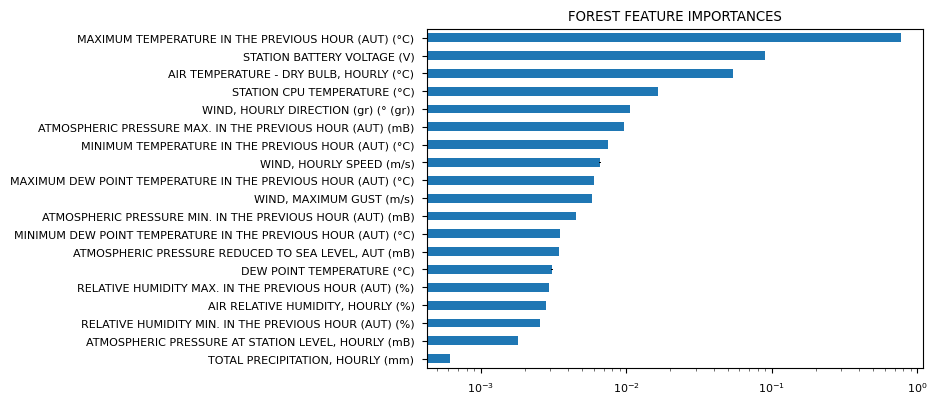

In [52]:
importances = model.feature_importances_
std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)
forest_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending =True)
fig, ax =plt.subplots()
forest_importances.plot.barh(yerr =std, ax =ax)
ax.set_xscale('log')
plt.title('FOREST FEATURE IMPORTANCES')
plt.savefig('Resultados/Forestfeatureimportances.jpeg')
plt.show()

## Feature importance by Permutation

In [21]:
from sklearn.inspection import permutation_importance
r = permutation_importance(model, X_test, y_test, scoring='neg_mean_squared_error')

In [22]:
def plot_feature_importances(perm_importance_result, feat_name):
    """bar plot the feature importance"""

    fig, ax = plt.subplots()

    indices = perm_importance_result["importances_mean"].argsort()
    plt.barh(
        range(len(indices)),
        perm_importance_result["importances_mean"][indices],
        xerr=perm_importance_result["importances_std"][indices],
    )
    ax.set_yticks(range(len(indices)))
    ax.set_title('PERMUTATION IMPORTANCE', loc ='left')
    # plt.tight_layout()
    plt.savefig('Resultados/Permutationimportance01.jpeg')
    _ = ax.set_yticklabels(feat_name[indices])

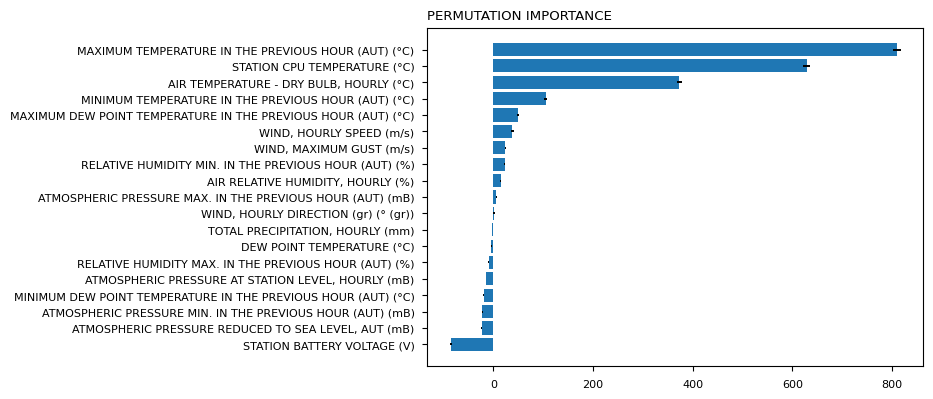

In [70]:
plot_feature_importances(r,X_train.columns)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# Dados simulados (substitua pelos seus valores reais)
feature_names = X_train.columns
forest_importances = pd.Series(r.importances_mean, index=feature_names).sort_values()

# Transformar em DataFrame para Seaborn
importance_df = forest_importances.reset_index()
importance_df.columns = ["Feature", "Importance"]
importance_df['Importance'] = importance_df['Importance'].abs()
# Criar o gráfico com Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", y="Feature", data=importance_df, 
    palette="viridis", orient="h"
)

# Configurações do gráfico
plt.xscale('log')  # Escala logarítmica no eixo X
plt.title("Feature Importances Using Permutation on Full Model", fontsize=14)
plt.xlabel("Mean Accuracy Decrease", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Mostrar o gráfico
plt.tight_layout()
plt.show()

## Feature Importance by Estatistics

### Variance

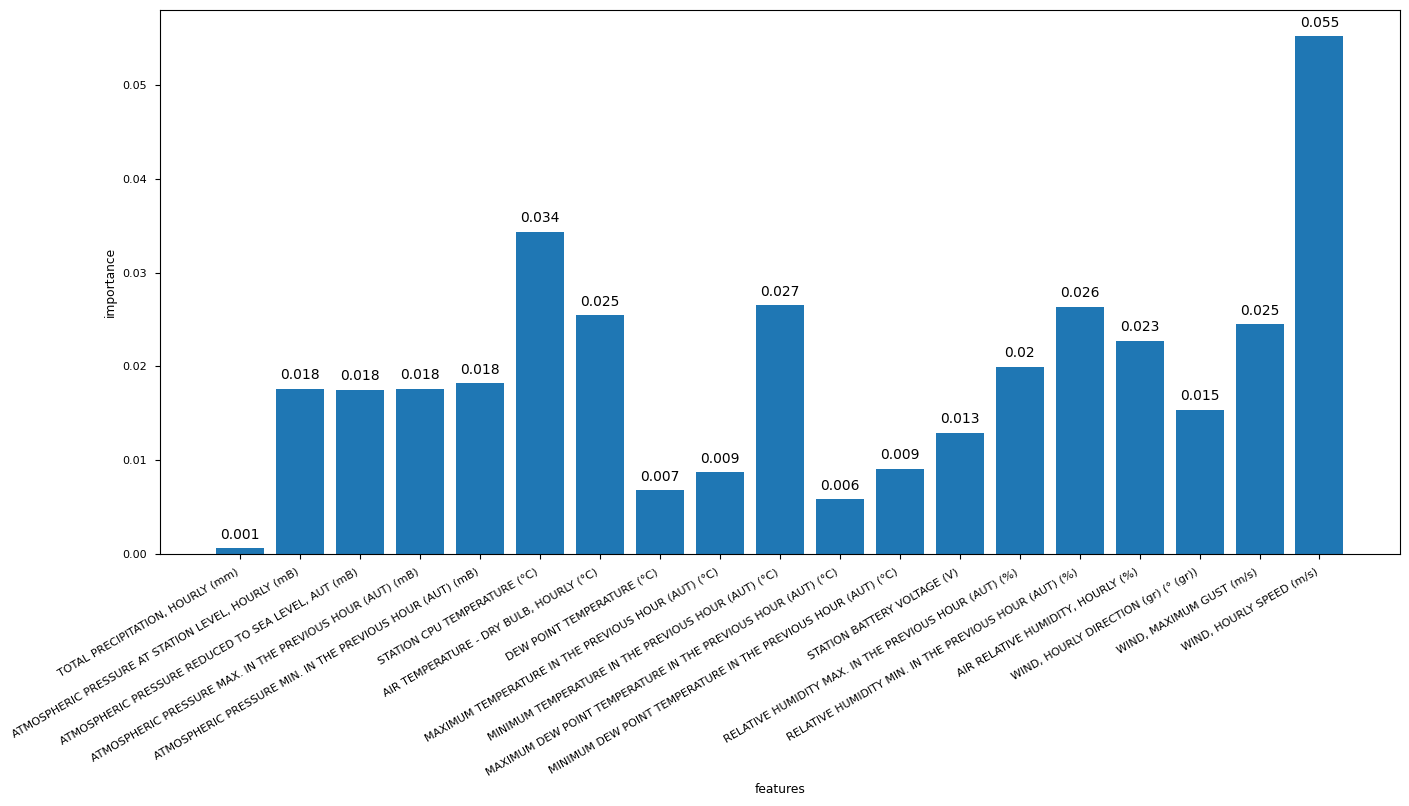

In [4]:

fig, ax = plt.subplots(figsize = (16,8))

x = X.columns
y = X_train_scaled.var(axis=0)

ax.bar(x,y)
ax.set_xlabel('features')
ax.set_ylabel('importance')
# ax.set_ylim()
for i, v in enumerate(y):
    plt.text(x = i, y = v + 0.001, s = str(round(v, 3)), ha='center')

fig.autofmt_xdate()
# plt.tight_layout()
plt.show()

In [26]:
variances_dict = {'features':X.columns,'variance':y}
variances_df = pd.DataFrame(variances_dict)
variances_df

,features,variance
0,"TOTAL PRECIPITATION, HOURLY (mm)",0.000610
1,"ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY ...",0.017617
2,"ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT...",0.017511
3,ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR...,0.017632
4,ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR...,0.018208
5,STATION CPU TEMPERATURE (°C),0.034375
6,"AIR TEMPERATURE - DRY BULB, HOURLY (°C)",0.025488
7,DEW POINT TEMPERATURE (°C),0.006827
8,MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT)...,0.008744
9,MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT)...,0.026570


In [37]:
y.mean()

np.float64(0.0192463500573115)

In [ ]:
features_var = list(variances_df['features'])
features_selected = []
cc = 0
for n in variances_df['variance']:
    if n > 0.020:
        print(f'{n}: {features[cc]}')
        features_selected.append(features[cc])
    cc = cc+1

In [59]:
X_train_var = X_train[features_selected]
X_test_var = X_test[features_selected]

In [58]:
for f in features_selected:
    print(f)

STATION CPU TEMPERATURE (°C)
AIR TEMPERATURE - DRY BULB, HOURLY (°C)
MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)
RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%)
AIR RELATIVE HUMIDITY, HOURLY (%)
WIND, MAXIMUM GUST (m/s)
WIND, HOURLY SPEED (m/s)


In [ ]:
pred_varSelect = []
metrics_varSelect = []
for k in scalersKeys:
    scaler = scalers[k]
    print(scaler)
    scaler_x = scaler
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled  = scaler_x.fit_transform(X_test)
    scaler_y = scaler
    y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
    print(X_train_scaled.shape, y_train_scaled.shape, X_test_scaled.shape)    
    for m in keys:
        model = models[m]
        print(m)
        model.fit(X_train_scaled, y_train_scaled)
        predict = model.predict(X_test_scaled)
        predict = scaler_y.inverse_transform(predict.reshape(-1,1)).ravel()
        predict_dic = {'Model':m,'Scaler':k,'estimation':predict}
        pred_varSelect.append(predict_dic)
        metrics = calcular_metricas(y_test, predict)
        metrics_dic = {'Model':m,'Scaler':k,'metrics':metrics}
        metrics_varSelect.append(metrics_dic)     

In [ ]:
metrics_varSelect

### Correlation

In [ ]:
corr_matrix = df.corr()
# Calculando a correlação das variáveis com a variável alvo
corr_with_target = corr_matrix['RADIACAO GLOBAL(Kj/m²)'].sort_values(ascending=True)

# Criando o gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(corr_with_target.index, corr_with_target.values)  # Usando barh para gráfico horizontal

# Adicionando rótulos e título
ax.set_xlabel('Correlação')
ax.set_title('Correlação das variáveis com RADIACAO GLOBAL(Kj/m²)')
# plt.tight_layout()
plt.show()

## Feature Selection (Select KBest)

In [147]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression

score_list = []
# model = models['XGB']

for k in range(1, len(X_train.columns)+1):
    selector = SelectKBest(mutual_info_regression, k=k)
    selector.fit(X_train, y_train)
    
    sel_X_train_v2 = selector.transform(X_train)
    sel_X_test_v2 = selector.transform(X_test)
    
    model.fit(sel_X_train_v2, y_train)
    kbest_preds = model.predict(sel_X_test_v2)
    
    score_kbest = calcular_metricas(y_test, kbest_preds)
    score_list.append(score_kbest)

score_list

[{'MSE': np.float64(206582.26827206052),
  'RMSE': np.float64(454.5132212291085),
  'MAE': np.float64(279.12679906931925),
  'MAPE': np.float64(19512325220250.67),
  'R²': 0.7536064699608245,
  'EVS': 0.7756754730542982},
 {'MSE': np.float64(199294.0970642784),
  'RMSE': np.float64(446.4236743994189),
  'MAE': np.float64(270.9271995981104),
  'MAPE': np.float64(33663842815662.113),
  'R²': 0.7622991726135534,
  'EVS': 0.7839028640386984},
 {'MSE': np.float64(200666.67160568575),
  'RMSE': np.float64(447.9583369083399),
  'MAE': np.float64(270.10157916191395),
  'MAPE': np.float64(16423717681152.17),
  'R²': 0.7606620839644256,
  'EVS': 0.7674789349499826},
 {'MSE': np.float64(205654.85865880665),
  'RMSE': np.float64(453.4918507082643),
  'MAE': np.float64(273.9213600884292),
  'MAPE': np.float64(9037486325642.754),
  'R²': 0.7547126042399821,
  'EVS': 0.7613684904644241},
 {'MSE': np.float64(176766.39590044515),
  'RMSE': np.float64(420.4359593332201),
  'MAE': np.float64(253.64729337

In [148]:
scores_forplot = []
for n in range(len(score_list)):
    print(score_list[n]['MSE'])
    scores_forplot.append(score_list[n]['MSE'])
# score_list[1]['R²']

206582.26827206052
199294.0970642784
200666.67160568575
205654.85865880665
176766.39590044515
167515.90262698228
161109.34241372618
167817.96535876163
158388.10150385022
161963.1067327669
161586.7494750332
151473.3988402971
150882.693634196
148982.16888161405
150760.56084100273
143345.31850195877
139402.2165795288
137691.65484100374
138254.51006023478


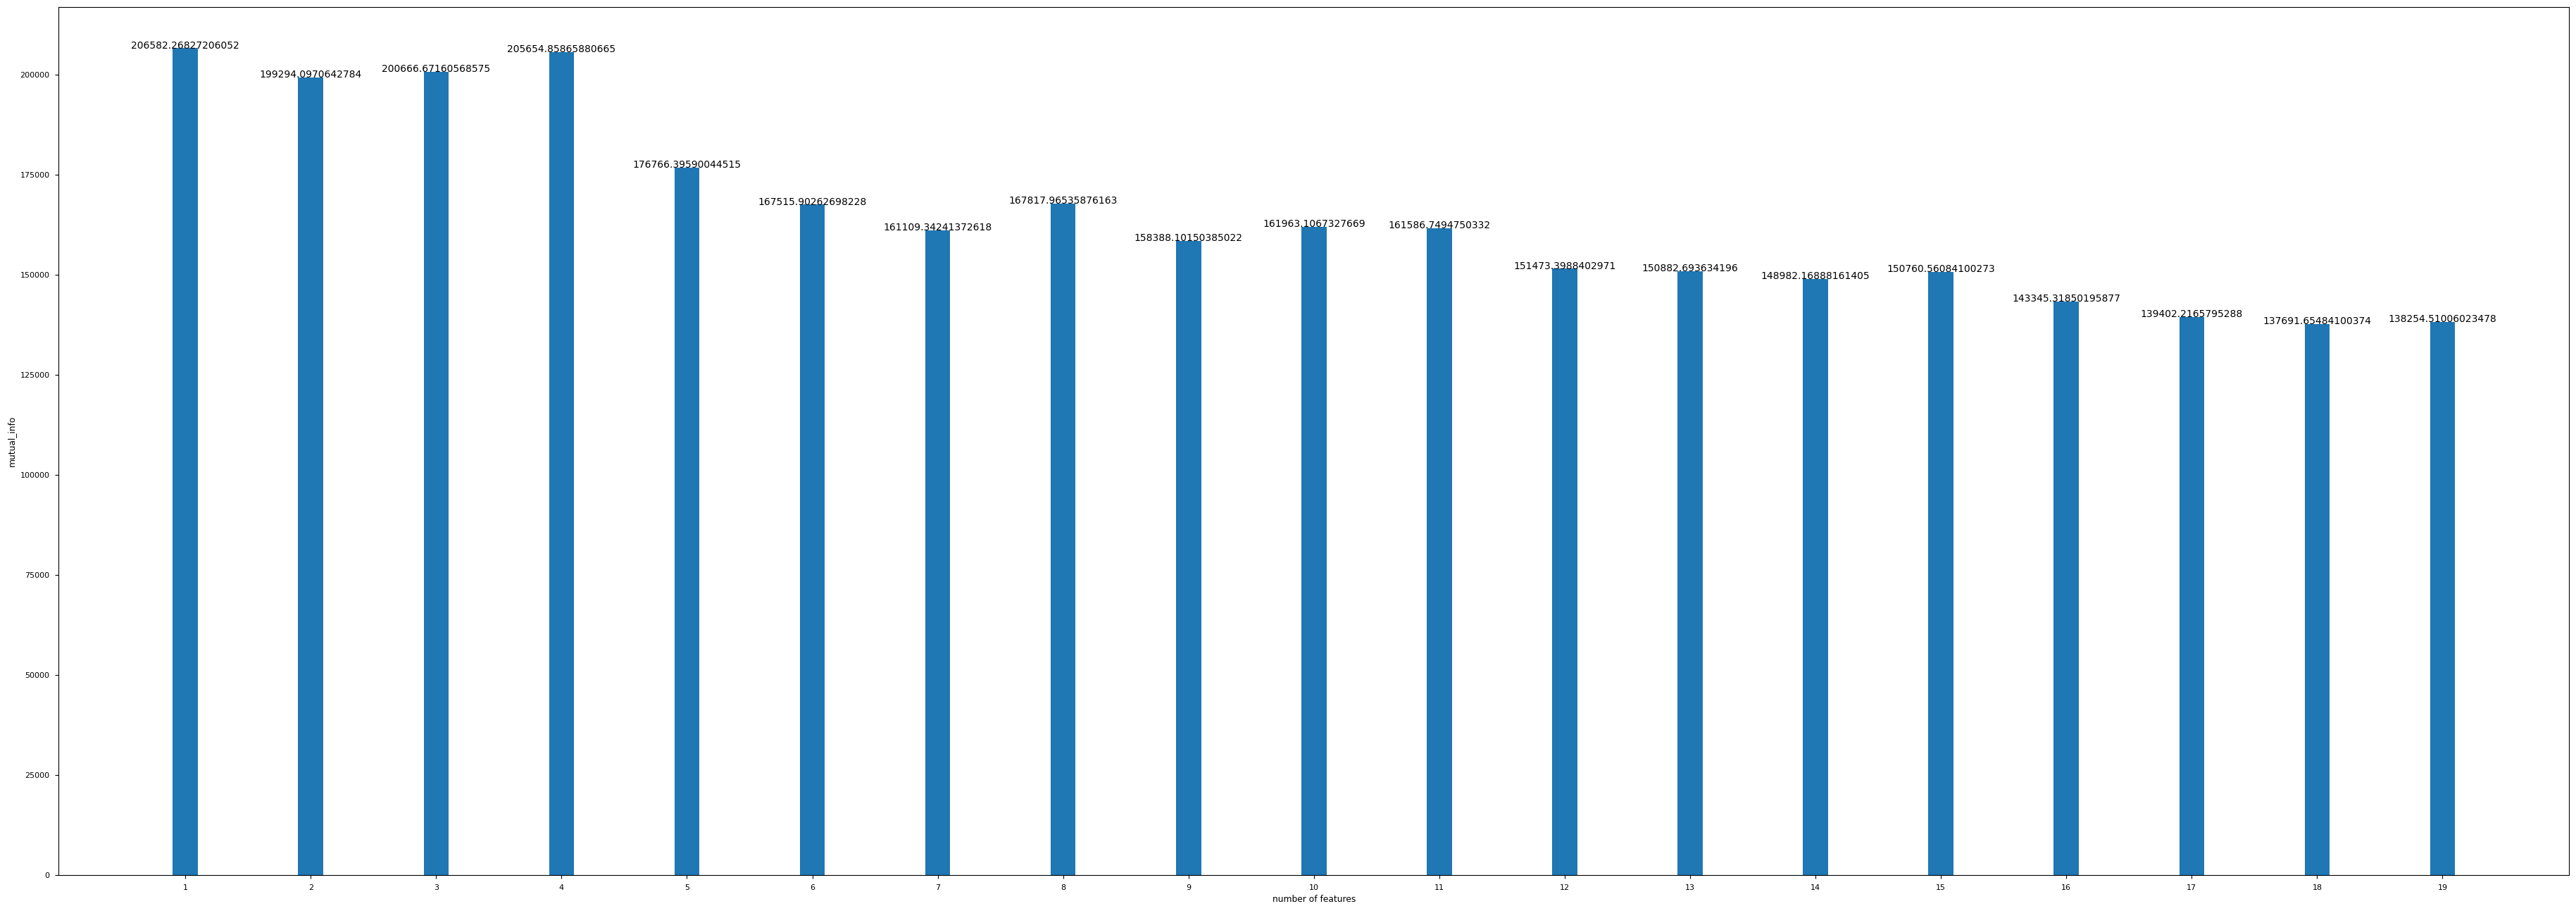

In [151]:

fig, ax = plt.subplots(figsize=(46,16))
x = np.arange(1,len(X_train.columns)+1)
y = scores_forplot

ax.bar(x,y, width=0.2)
ax.set_xlabel('number of features')
ax.set_ylabel('mutual_info')
# ax.set_ylim(0,0.8)
ax.set_xticks(np.arange(1,len(X_train.columns)+1))
# ax.set_xticklabels(np.arange(1,24), fontsize=12)
for i, v in enumerate(y):
    plt.text(x=i+1, y = v+0.05, s = str(v), ha= 'center')

# plt.tight_layout()
plt.savefig('Resultados/selectkbestmse.jpeg')
plt.show()

In [156]:
int(min(scores_forplot))

137691

In [174]:
n = 0
for i in scores_forplot:
    if i == int(min(scores_forplot)):
        print(f'numero de features selecionadas: {n}')

    else:
        if n < len(scores_forplot):
            print(i)
        else:
            i != int(min(scores_forplot))
            print(scores_forplot[n])
            n +=1

        
# print(f'numero de features selecionadas: {n}')

206582.26827206052
199294.0970642784
200666.67160568575
205654.85865880665
176766.39590044515
167515.90262698228
161109.34241372618
167817.96535876163
158388.10150385022
161963.1067327669
161586.7494750332
151473.3988402971
150882.693634196
148982.16888161405
150760.56084100273
143345.31850195877
139402.2165795288
137691.65484100374
138254.51006023478


In [ ]:
selector = SelectKBest(mutual_info_regression, k=n)
selector.fit(X_train, y_train)

selected_feature_mask = selector.get_support()

selected_features = X_train_v2.columns[selected_feature_mask]

selected_features

## Feature Importance Wrapper Method

In [57]:
from sklearn.feature_selection import RFE

rfe_metrics = []

for c in range(1,len(X_train.columns)+1):
    print(c)
    selector = RFE(model, n_features_to_select = c, step=1)
    selector = selector.fit(X_train,y_train)
    
    rfe_X_train = selector.transform(X_train)
    rfe_X_test = selector.transform(X_test)
    
    model.fit(rfe_X_train,y_train)
    rfe_forestmodelpreds = model.predict(rfe_X_test)
    
    rfe_forestmodelCalcMetrics = calcular_metricas(y_test,rfe_forestmodelpreds)  
    rfe_metrics.append(rfe_forestmodelCalcMetrics)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [67]:
scores_forplot = []
for n in range(len(rfe_metrics)):
    print(rfe_metrics[n]['MSE'])
    scores_forplot.append(rfe_metrics[n]['MSE'])

206771.0174956138
225010.28701771278
217330.87363141164
195755.84582665158
172579.21354244524
173382.5426906
156572.85213899828
156864.24842951744
145010.0437159736
145939.45875461824
146052.36043877783
147261.4365028047
143680.17884198952
145327.05826380363
144649.01513312286
145318.71602516444
145030.58755191826
147324.70984273235
145151.97206210077


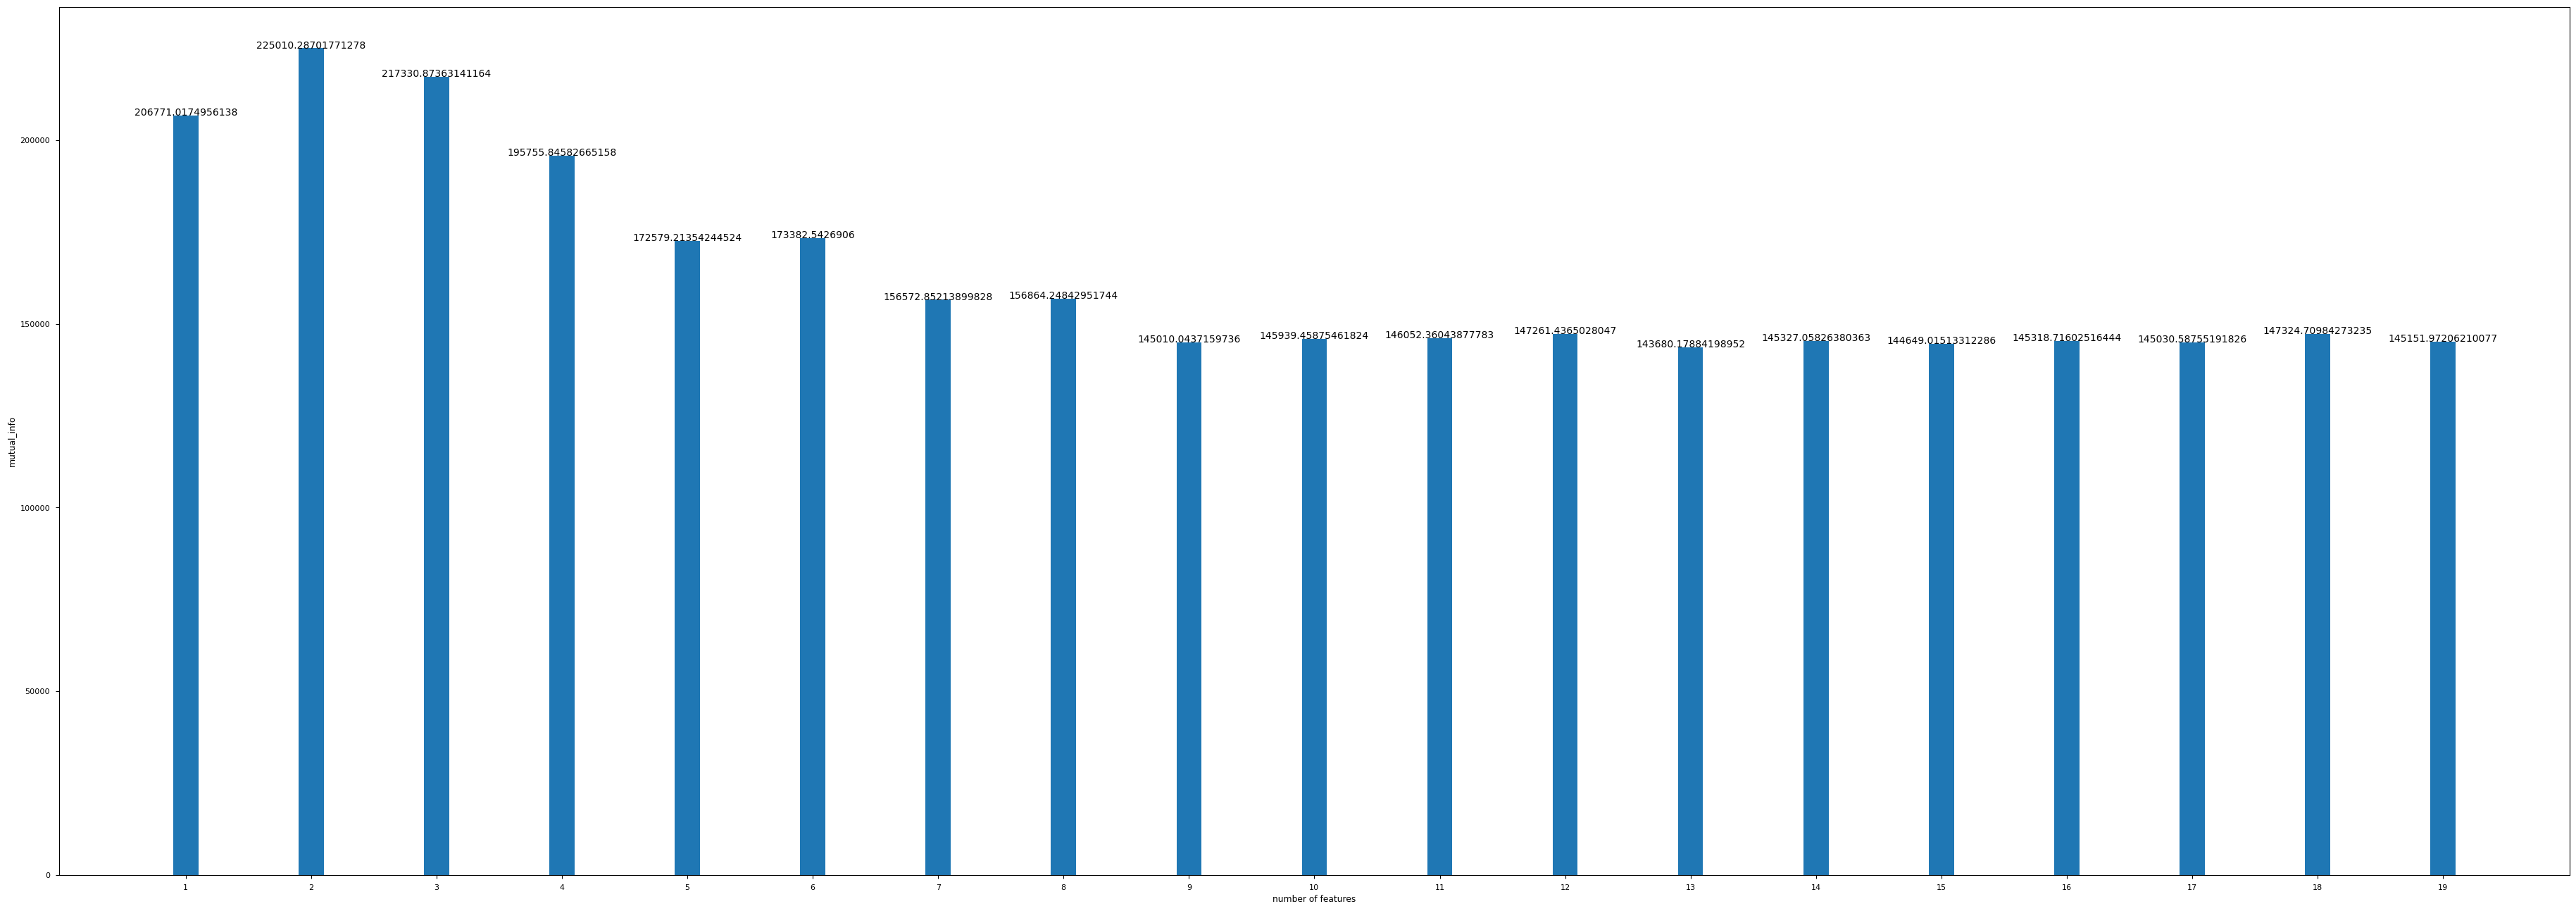

In [69]:

fig, ax = plt.subplots(figsize=(46,16))
x = np.arange(1,len(X_train.columns)+1)
y = scores_forplot

ax.bar(x,y, width=0.2)
ax.set_xlabel('number of features')
ax.set_ylabel('mutual_info')
# ax.set_ylim(0,0.8)
ax.set_xticks(np.arange(1,len(X_train.columns)+1))
# ax.set_xticklabels(np.arange(1,24), fontsize=12)
for i, v in enumerate(y):
    plt.text(x=i+1, y = v+0.05, s = str(v), ha= 'center')

# plt.tight_layout()
imgpath = 'output/rfe_metrics_mse.jpeg'
plt.savefig(imgpath)
plt.show()

In [71]:
n = 0
minimo = min(scores_forplot)
print(f'Mínimo: {minimo}')

for i in scores_forplot:
    if i == minimo:
        print(f'Número de features selecionadas: {n}')
        break  # Interrompe o loop ao encontrar o valor mínimo
    else:
        print(i)
    n += 1

Mínimo: 143680.17884198952
206771.0174956138
225010.28701771278
217330.87363141164
195755.84582665158
172579.21354244524
173382.5426906
156572.85213899828
156864.24842951744
145010.0437159736
145939.45875461824
146052.36043877783
147261.4365028047
Número de features selecionadas: 12


In [75]:
selector = RFE(model, n_features_to_select=n,step =10)
selector.fit(X_train, y_train)

selected_feature_mask = selector.get_support()

selected_features = X_train.columns[selected_feature_mask]

selected_features

Index(['ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB)',
       'ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB)',
       'STATION CPU TEMPERATURE (°C)',
       'AIR TEMPERATURE - DRY BULB, HOURLY (°C)',
       'MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MAXIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MINIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'STATION BATTERY VOLTAGE (V)', 'WIND, HOURLY DIRECTION (gr) (° (gr))',
       'WIND, MAXIMUM GUST (m/s)', 'WIND, HOURLY SPEED (m/s)'],
      dtype='object')

## SHAP

In [47]:
import pandas as pd
import shap
from sklearn.ensemble import RandomForestRegressor

df = pd.read_parquet('FormatDataSalinas.gzip')
model = RandomForestRegressor(n_jobs=-1)

In [22]:
df = df[(df.index.hour >= 11) & (df.index.hour <=21)]

y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')
print(f'Tamanho da Base de dados: {len(X)}')

size = 0.02
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

Tamanho da Base de dados: 40788
Tamanho da base de treino: 0.02
Treino: 815, Teste: 39973


In [23]:
model.fit(X_train, y_train)

explainer = shap.Explainer(model)
shap_values = explainer(X_train)

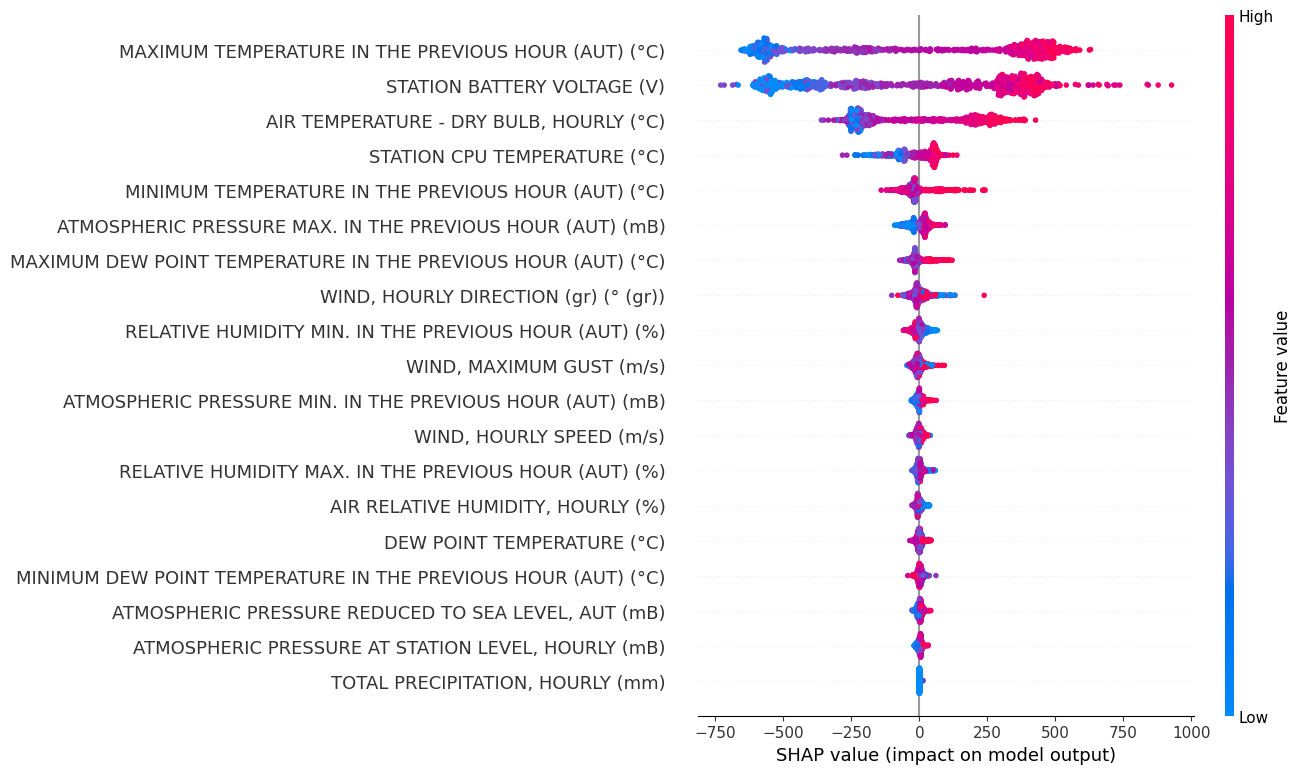

In [24]:
shap.plots.beeswarm(shap_values, max_display =22)

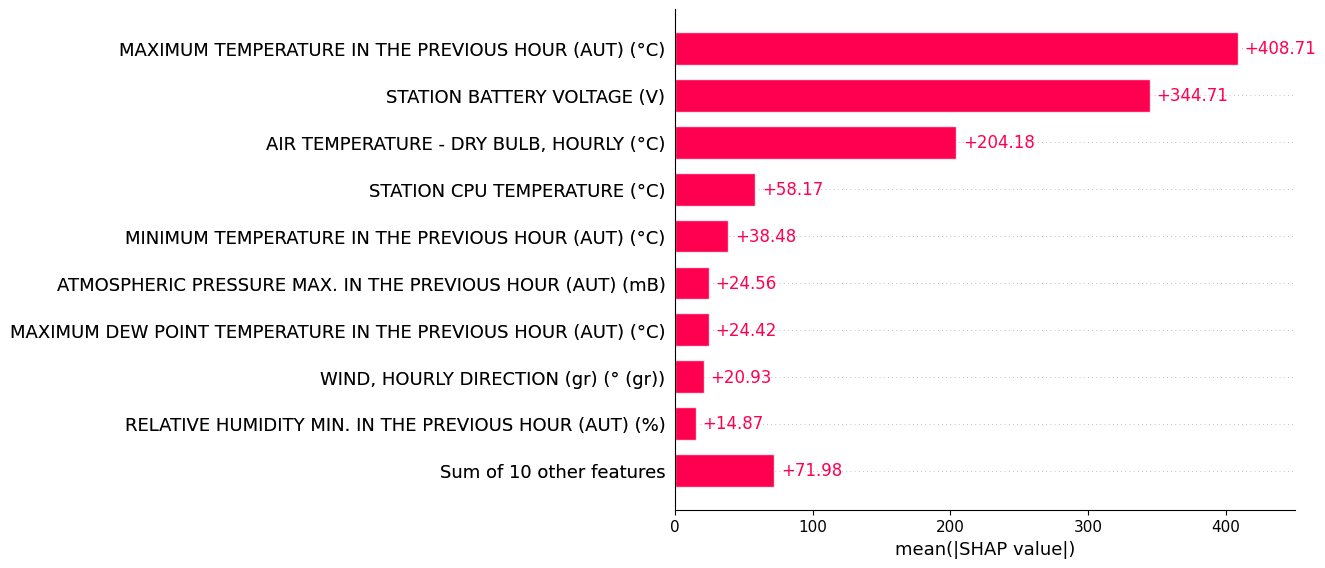

In [25]:
shap.plots.bar(shap_values)

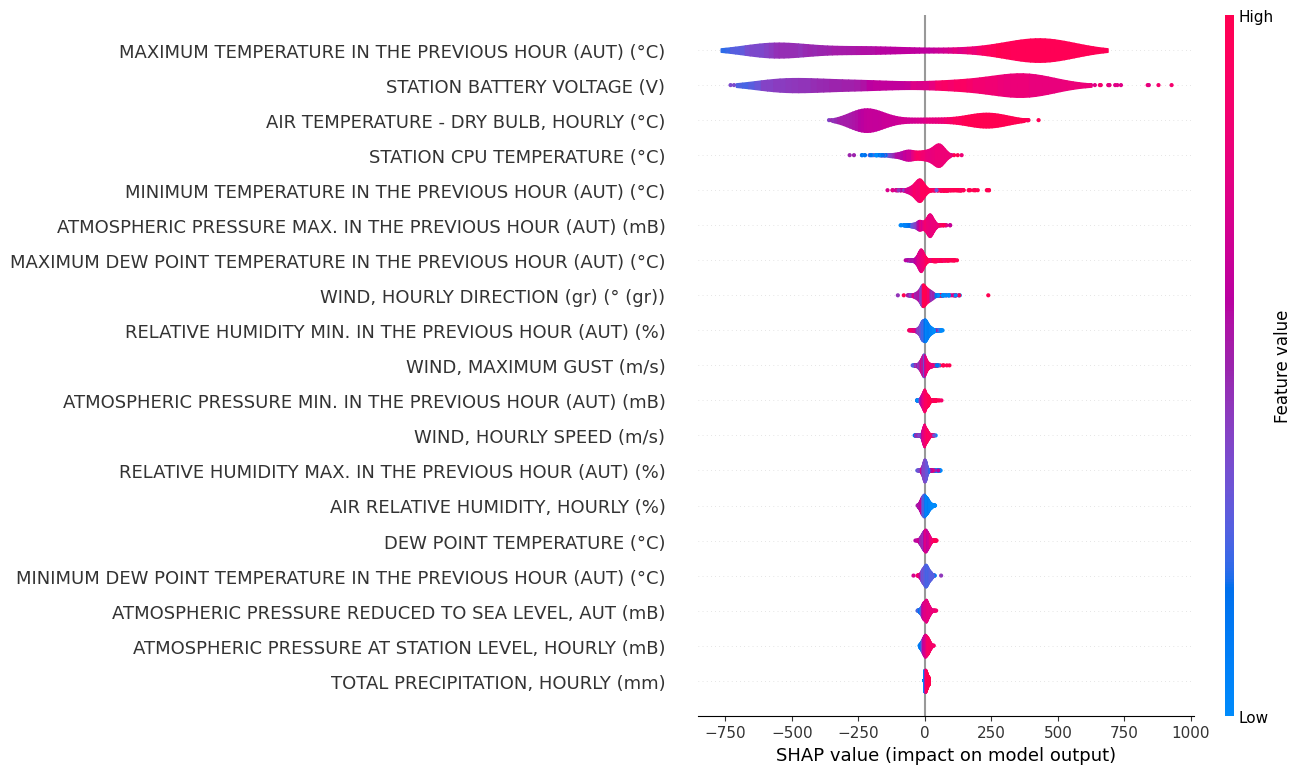

In [26]:
shap.plots.violin(shap_values)

# Feature Enginering

## New Features

In [48]:
df = df[(df.index.hour >= 11) & (df.index.hour <=21)]
df['SMA_5'] = df['GLOBAL RADIATION (Kj/m²)'].rolling(window=5,center =True).mean()

In [ ]:

df.dropna(inplace=True)
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')
print(f'Tamanho da Base de dados: {len(X)}')

size = 0.02
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler_x = MinMaxScaler()
X_train_scaled_v3 = scaler_x.fit_transform(X_train)
scaler_y = MinMaxScaler()
y_train_scaled_v3 = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()

model.fit(X_train_scaled_v3, y_train_scaled_v3)

explainer = shap.Explainer(model)
shap_values = explainer(X_train_scaled_v3)

Tamanho da Base de dados: 40784
Tamanho da base de treino: 0.02
Treino: 815, Teste: 39969


In [ ]:
feature_names = list(X_train.columns)
feature_names

['TOTAL PRECIPITATION, HOURLY (mm)',
 'ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)',
 'ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT (mB)',
 'ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB)',
 'ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB)',
 'STATION CPU TEMPERATURE (°C)',
 'AIR TEMPERATURE - DRY BULB, HOURLY (°C)',
 'DEW POINT TEMPERATURE (°C)',
 'MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
 'MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
 'MAXIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
 'MINIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
 'STATION BATTERY VOLTAGE (V)',
 'RELATIVE HUMIDITY MAX. IN THE PREVIOUS HOUR (AUT) (%)',
 'RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%)',
 'AIR RELATIVE HUMIDITY, HOURLY (%)',
 'WIND, HOURLY DIRECTION (gr) (° (gr))',
 'WIND, MAXIMUM GUST (m/s)',
 'WIND, HOURLY SPEED (m/s)',
 'SMA_5']

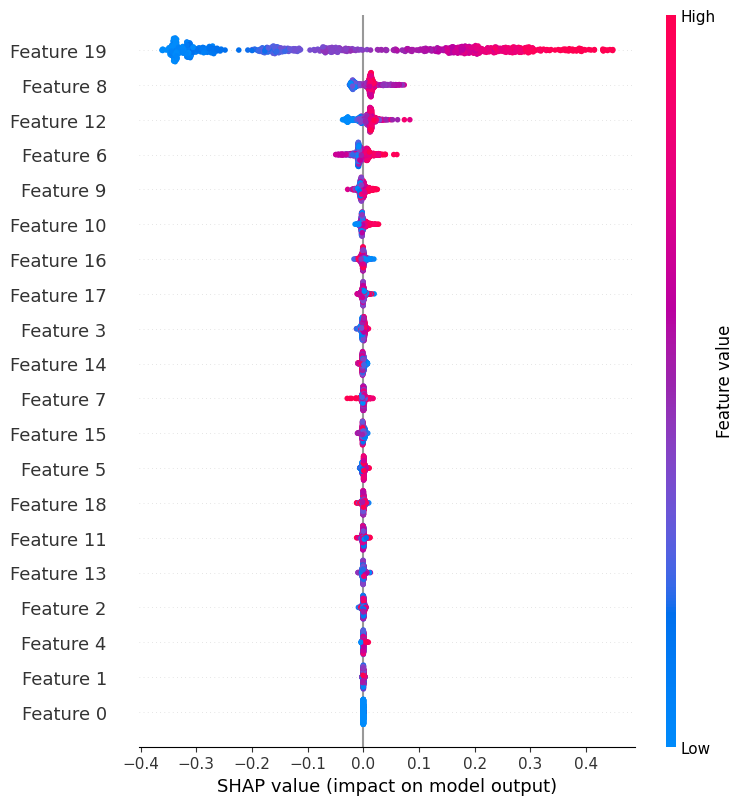

In [28]:
shap.plots.beeswarm(shap_values, max_display =22)

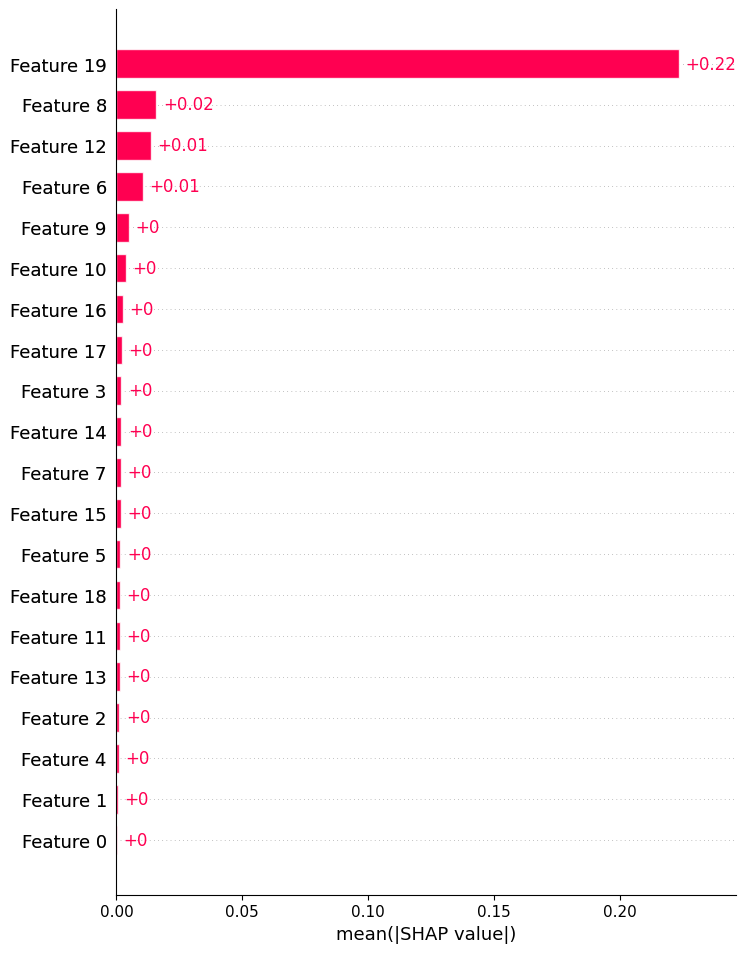

In [29]:
shap.plots.bar(shap_values, max_display =22)

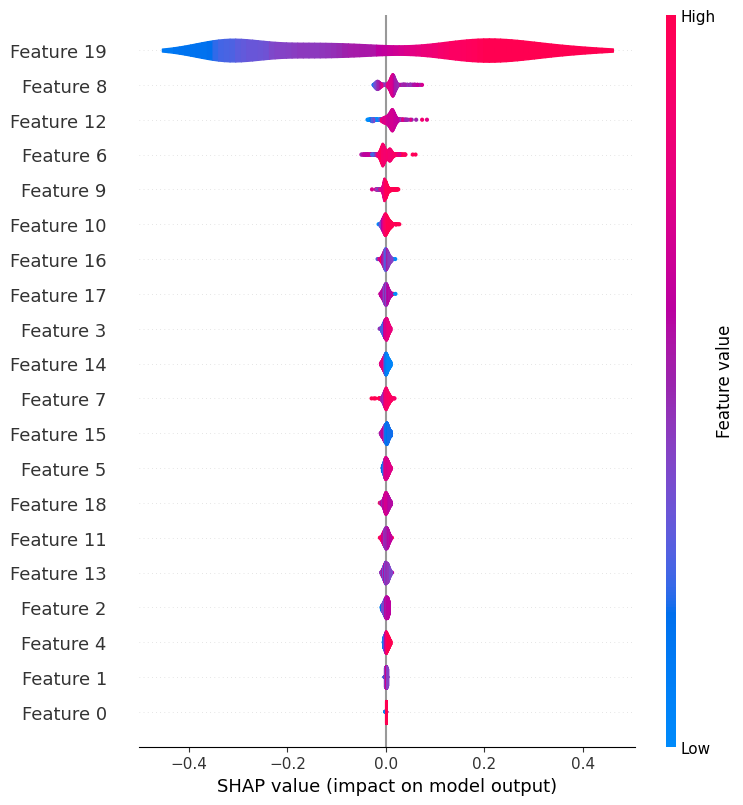

In [30]:
shap.plots.violin(shap_values, max_display =22)

### Do the article of feature enginering steps

### Termic Sense

In [40]:
feature_names

['TOTAL PRECIPITATION, HOURLY (mm)',
 'ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)',
 'ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT (mB)',
 'ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB)',
 'ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB)',
 'STATION CPU TEMPERATURE (°C)',
 'AIR TEMPERATURE - DRY BULB, HOURLY (°C)',
 'DEW POINT TEMPERATURE (°C)',
 'MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
 'MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
 'MAXIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
 'MINIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
 'STATION BATTERY VOLTAGE (V)',
 'RELATIVE HUMIDITY MAX. IN THE PREVIOUS HOUR (AUT) (%)',
 'RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%)',
 'AIR RELATIVE HUMIDITY, HOURLY (%)',
 'WIND, HOURLY DIRECTION (gr) (° (gr))',
 'WIND, MAXIMUM GUST (m/s)',
 'WIND, HOURLY SPEED (m/s)',
 'SMA_5']

In [49]:
df['windSpeed_km_h'] = df['WIND, HOURLY SPEED (m/s)'] * 3.6
df['ST'] = 33 + (10 * np.sqrt(df['windSpeed_km_h']) + 10.45 - df['windSpeed_km_h']) * (df['AIR TEMPERATURE - DRY BULB, HOURLY (°C)'] - 33) / 22

In [53]:
df.dropna(inplace=True)
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')
print(f'Tamanho da Base de dados: {len(X)}')

size = 0.02
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler_x = MinMaxScaler()
X_train_scaled_v3 = scaler_x.fit_transform(X_train)
scaler_y = MinMaxScaler()
y_train_scaled_v3 = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()

# model.fit(X_train_scaled_v3, y_train_scaled_v3)
model.fit(X_train, y_train)
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

Tamanho da Base de dados: 40784
Tamanho da base de treino: 0.02
Treino: 815, Teste: 39969


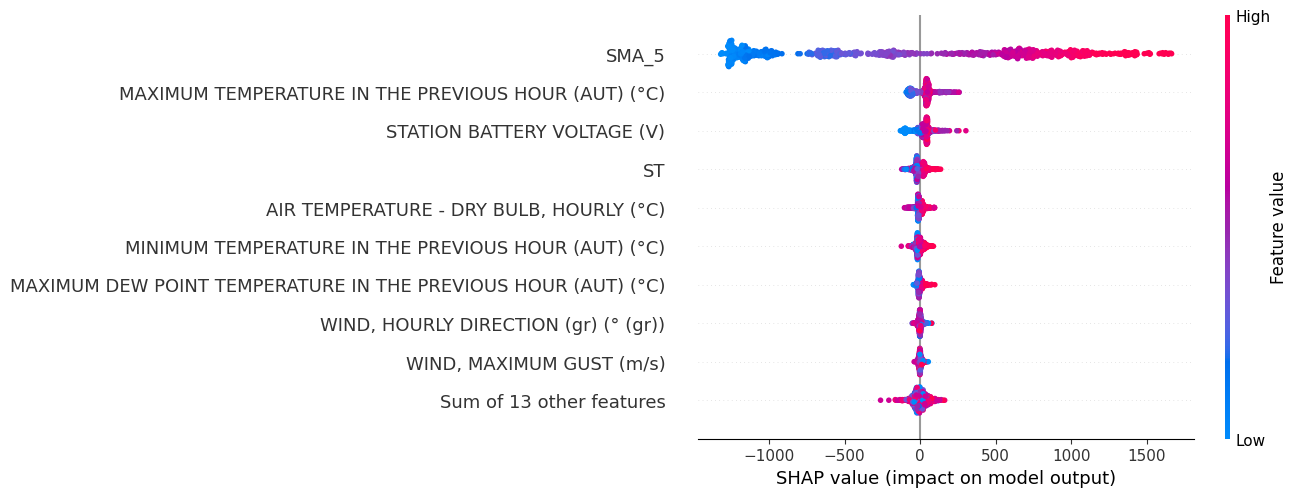

In [54]:
shap.plots.beeswarm(shap_values)

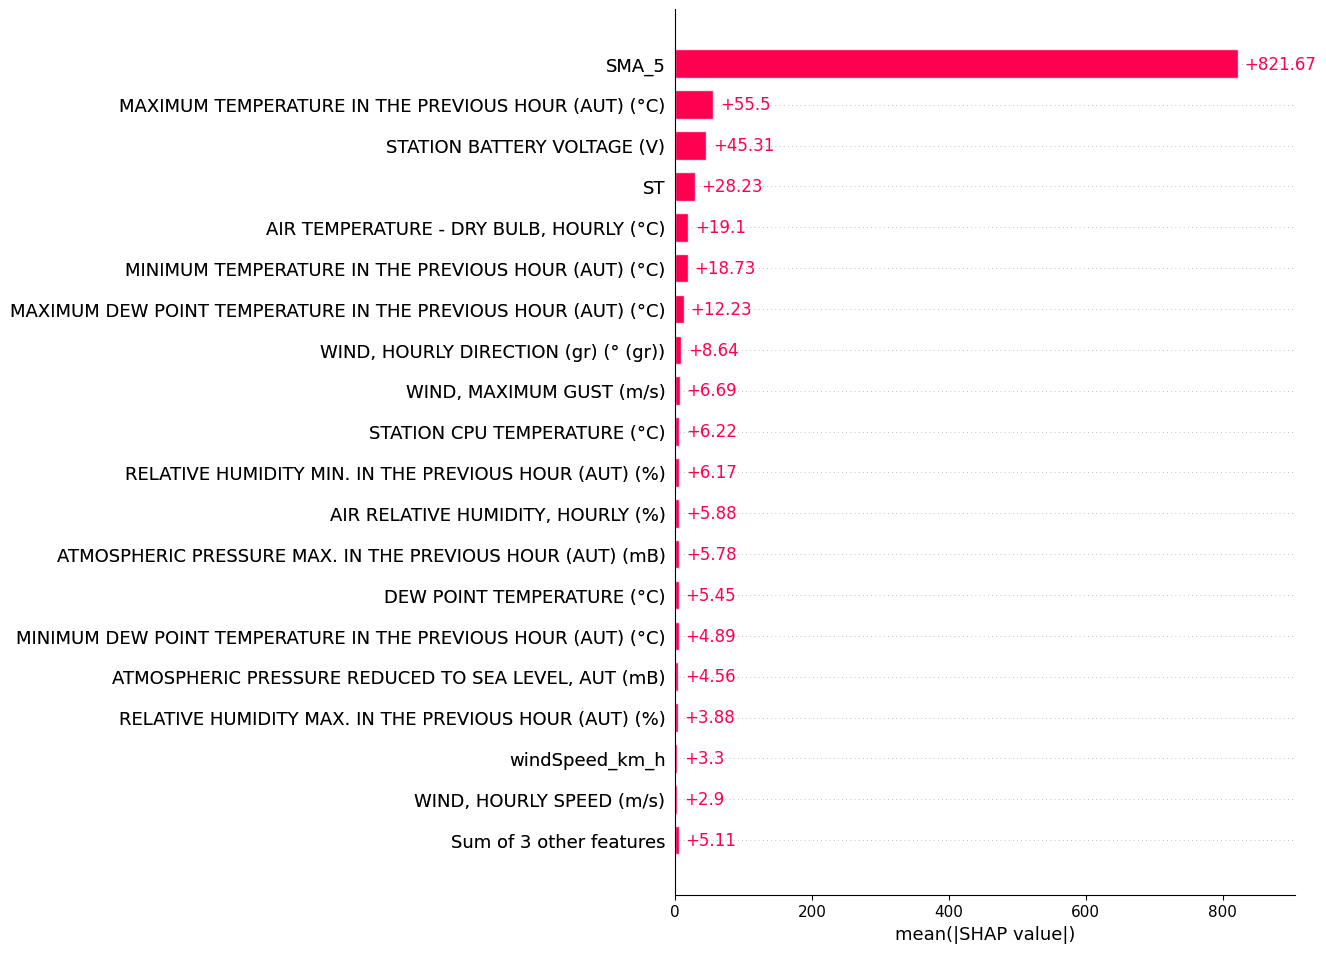

In [55]:
shap.plots.bar(shap_values, max_display=20)

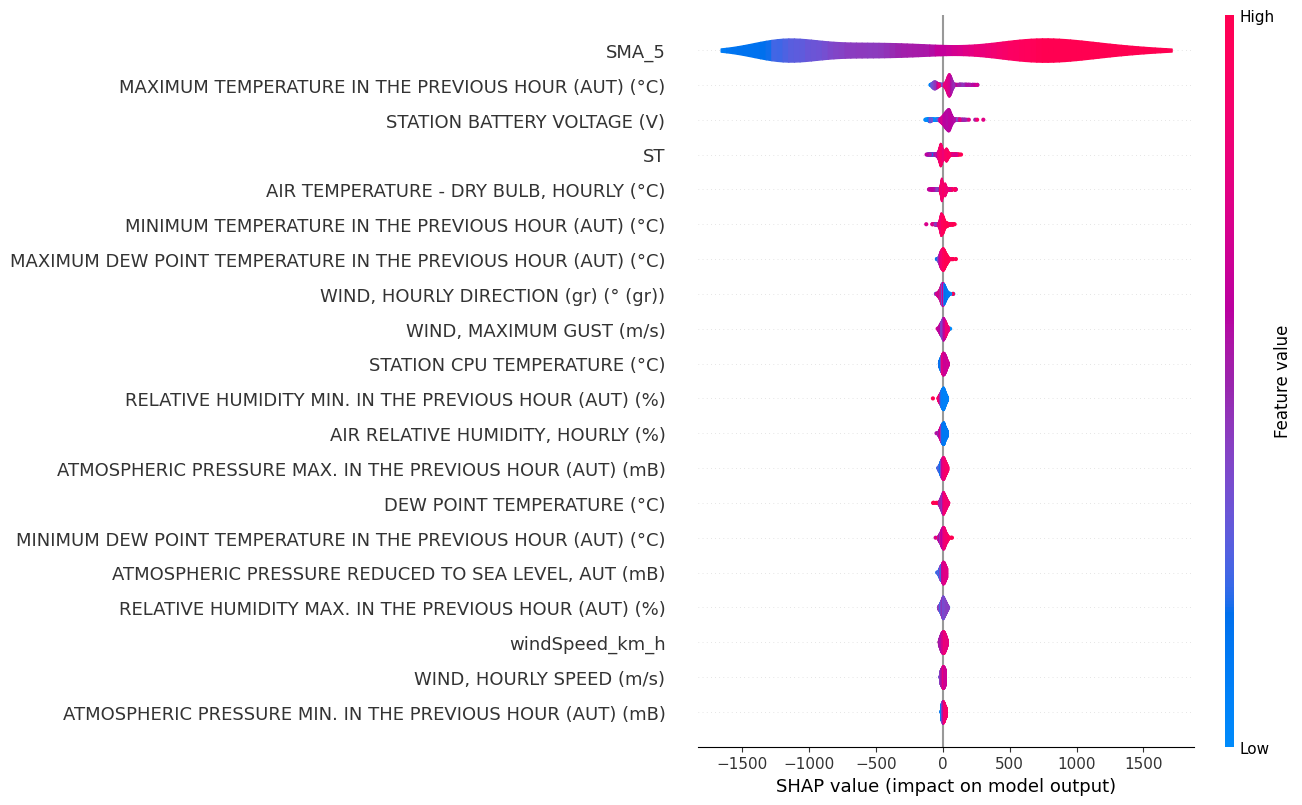

In [56]:
shap.plots.violin(shap_values)

## Usando RNA Perceptron multicamadas

In [48]:
import tensorflow
from tensorflow.keras import layers, models
import tf_levenberg_marquardt as lm
import pandas as pd
import numpy as np
import keras

In [49]:
def calcular_metricas(y_test, y_pred):
    return {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred),
        'EVS': explained_variance_score(y_test, y_pred),
    }

def calculate_moving_averages(df, window_size):
    df['moving_average'] = df['GLOBAL RADIATION (Kj/m²)'].rolling(window=window_size).mean()

    df['central_mean'] = df['GLOBAL RADIATION (Kj/m²)'].rolling(window=window_size, center=True).mean()

    return df

def sensacao_termica(df):
    df['windSpeed_km_h'] = df['WIND, HOURLY SPEED (m/s)'] * 3.6
    df['ST'] = 33 + (10 * np.sqrt(df['windSpeed_km_h']) + 10.45 - df['windSpeed_km_h']) * (df['AIR TEMPERATURE - DRY BULB, HOURLY (°C)'] - 33) / 22
    df.drop(columns=['windSpeed_km_h'], inplace =True)
    return df

In [50]:
df = pd.read_parquet('FormatDataSalinas.gzip')
df = df[(df.index.hour >= 11) & (df.index.hour <=21)]
df = calculate_moving_averages(df,5)
df = sensacao_termica(df)
df.dropna(inplace=True)

In [51]:
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')
print(f'Tamanho da Base de dados: {len(X)}')

size = 0.8
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler = MinMaxScaler()
scaler_x = scaler
X_train_scaled_v4 = scaler_x.fit_transform(X_train)
X_test_scaled_v4 = scaler_x.transform(X_test)
scaler_y = scaler
y_train_scaled_v4 = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
y_test_scaled_v4 = scaler_y.transform(y_test.to_numpy().reshape(-1,1)).ravel()

Tamanho da Base de dados: 40782
Tamanho da base de treino: 0.8
Treino: 32625, Teste: 8157


In [67]:
'''import tensorflow as tf
from tensorflow.keras import layers
import keras_tuner as kt

# Função para construir o modelo
def build_model(hp):
    model = tf.keras.Sequential([
        # A definição dos neurônios com valores de hp
        layers.Dense(units=hp.Int('units', 
                                  min_value=8, 
                                  max_value=128, 
                                  step=8), 
                     activation='relu',
                     layers
                     input_shape=(X_train.shape[1],)),
        layers.Dense(1, activation='linear')
    ])
    
    # Definir o otimizador com a possibilidade de ajuste de hiperparâmetros
    optimizer = tf.keras.optimizers.Adam(
        hp.Float('learning_rate', 
                 min_value=1e-4, 
                 max_value=1e-2, 
                 sampling='log')
    )
    
    # Compilação do modelo
    model.compile(optimizer=optimizer, 
                  loss='mse', 
                  metrics=['mse'])
    return model'''

In [69]:
'''# Configuração do Keras Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='tune_neurons_tanh_movingaverage'
)

# Realizar a busca de hiperparâmetros
tuner.search(X_train_scaled_v4, y_train_scaled_v4,
              epochs=50, 
              validation_split=0.2, 
              verbose=1)

# Recuperar os melhores hiperparâmetros encontrados
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Melhor número de neurônios na camada densa: {best_hps.get('units')}")
print(f"Melhor taxa de aprendizado: {best_hps.get('learning_rate')}")'''

Trial 10 Complete [00h 00m 53s]
val_loss: 0.006001055706292391

Best val_loss So Far: 0.0050831809639930725
Total elapsed time: 00h 09m 19s
Melhor número de neurônios na camada densa: 80
Melhor taxa de aprendizado: 0.006294486539785555


In [146]:
nhiddenlayers = [1,10,15,20]

nneurons = [8,16,24,32,40,48,
            56,64,72,80,88,96,
            104,112,120,128,136,
            144,152,160,168,176,
            184,192,200]

activation = ['relu','tanh']

lista_otimizadores = {'ADAM':tf.keras.optimizers.Adam(min_value=1e-4, max_value=1e-2, sampling='log'),
              'SGD':tf.keras.optimizers.SGD(min_value=1e-4, max_value=1e-2, sampling='log'),
              'RMS':tf.keras.optimizers.RMSprop(min_value=1e-4, max_value=1e-2, sampling='log')}
                    

TypeError: min_value is not a valid argument, kwargs should be empty  for `optimizer_experimental.Optimizer`.

In [131]:
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    for i in range(hp.Int('num_hidden_layers', min_value=1, max_value=15)):
        model.add(
            layers.Dense(
                units=hp.Int(f'units_layer_{i}', min_value=8, max_value=128, step=8),
                activation='relu'
            )
        )
    
    model.add(layers.Dense(1, activation='linear'))
    optimizer = tf.keras.optimizers.Adam(
        hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    )
    
    model.compile(optimizer=optimizer, 
                  loss='mse', 
                  metrics=['mse'])
    return model

In [132]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='tune_hidden_layers_15'
)

tuner.search(X_train_scaled_v4, y_train_scaled_v4,
             epochs=50, 
             validation_split=0.2, 
             verbose=1)

# Recuperar os melhores hiperparâmetros encontrados
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Exibir os melhores hiperparâmetros
print(f"Melhor número de camadas ocultas: {best_hps.get('num_hidden_layers')}")
for i in range(best_hps.get('num_hidden_layers')):
    print(f"Neurônios na camada {i + 1}: {best_hps.get(f'units_layer_{i}')}")
print(f"Melhor taxa de aprendizado: {best_hps.get('learning_rate')}")

Trial 10 Complete [00h 01m 07s]
val_loss: 0.004300241358578205

Best val_loss So Far: 0.004166408441960812
Total elapsed time: 00h 11m 54s
Melhor número de camadas ocultas: 4
Neurônios na camada 1: 72
Neurônios na camada 2: 80
Neurônios na camada 3: 96
Neurônios na camada 4: 24
Melhor taxa de aprendizado: 0.001395388438752399


In [133]:
def hypermodel():
    model = tensorflow.keras.Sequential([
        layers.Dense(units= 72,
                     activation= 'relu',
                     input_shape=(X_train.shape[1],)),
        layers.Dense(units= 80, activation= 'relu'),
        layers.Dense(units=96, activation= 'relu'),
        layers.Dense(units=24,  activation= 'relu'),
        # layers.Dense(units=88,  activation= 'relu'),
        layers.Dense(1,activation='linear')
    ])
    optimizer = tensorflow.keras.optimizers.Adam(learning_rate=0.001395388438752399
)
    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mse'])
    return model 

In [134]:
model = hypermodel()

In [135]:
model.fit(X_train_scaled_v4,y_train_scaled_v4)

1020/1020 [==============================] - 2s 1ms/step - loss: 0.0082 - mse: 0.0082


In [136]:
pred = model.predict(X_test_scaled_v4)

255/255 [==============================] - 0s 898us/step


In [137]:
calcular_metricas(y_test_scaled_v4, pred)

{'MSE': 0.007247633652290353,
 'RMSE': 0.08513303502337005,
 'MAE': 0.06618593584336138,
 'MAPE': 0.46766734357156153,
 'R²': 0.8291268928005388,
 'EVS': 0.8303127532744374}

In [140]:
model_wrapper = lm.model.ModelWrapper(model)

model_wrapper.compile(
    optimizer = tensorflow.keras.optimizers.SGD(learning_rate = 0.002),
    loss= lm.loss.MeanSquaredError(),
    metrics = ['mae','mse'])

model_wrapper.fit(X_train_scaled_v4, y_train_scaled_v4)

1020/1020 [==============================] - 25s 25ms/sample - damping_factor: 5.4566e-08 - attempts: 1.0000 - loss: 0.0051 - mae: 0.0522 - mse: 0.0050


In [141]:
pred_wrapper = model_wrapper.predict(X_test)
calcular_metricas(y_test_scaled_v4, pred_wrapper)

255/255 [==============================] - 1s 3ms/step


{'MSE': 1119170.7159215896,
 'RMSE': 1057.9086519740679,
 'MAE': 983.2297400414728,
 'MAPE': 4551.194526941633,
 'R²': -26386015.028243136,
 'EVS': -3593749.4559798497}

# Pipelines

In [156]:
col_num = list(df.select_dtypes('float64').columns)
col_num = [col for col in col_num if col != 'RADIACAO GLOBAL(Kj/m²)']
col_cat = list(df.select_dtypes('object').columns)

numeric_transformer = Pipeline(
    steps=[("scaler", RobustScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, col_num),
        ("cat", categorical_transformer, col_cat),
    ]
)

In [ ]:
from sklearn.compose import TransformedTargetRegressor
pipemodel = Pipeline(
    steps=[('preprocessing', preprocessor),
           ('estimator', model)])
pipemodelscaled = TransformedTargetRegressor(
    regressor = pipemodel,
    transformer = RobustScaler()
)
pipemodelscaled.fit(X_train, y_train)
pipepreds = pipemodelscaled.predict(X_test)
# pipemodel.fit(X_train, y_tr{'MSE': 0.009549973577041028,
 'RMSE': 0.09772396623674783,
 'MAE': 0.07380743714883561,
 'MAPE': 0.4022211847700723,
 'R²': 0.7748460067009497,
 'EVS': 0.7906604530428811}ain)
# pipepreds = pipemodel.predict(X_test)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error, mean_squared_error, explained_variance_score
def calcular_metricas(y_test, y_pred):
    return {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred),
        'EVS': explained_variance_score(y_test, y_pred),
    }

In [2]:
df = pd.read_parquet('FormatDataSalinas.gzip')
df = df[(df.index.hour > 11) & (df.index.hour <21)]
df['SMA_5'] = df['GLOBAL RADIATION (Kj/m²)'].rolling(window=5,center =True).mean()
df['windSpeed_km_h'] = df['WIND, HOURLY SPEED (m/s)'] * 3.6
df['ST'] = 33 + (10 * np.sqrt(df['windSpeed_km_h']) + 10.45 - df['windSpeed_km_h']) * (df['AIR TEMPERATURE - DRY BULB, HOURLY (°C)'] - 33) / 22
df.dropna(inplace =True)
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')

In [3]:
print(f'Tamanho da Base de dados: {len(X)}')

size = 0.6
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

scaler_x = MinMaxScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
x_test_scaled = scaler_x.transform(X_test)
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
y_test_scaled = scaler_y.transform(y_test.to_numpy().reshape(-1,1)).ravel()

Tamanho da Base de dados: 33385
Tamanho da base de treino: 0.6
Treino: 20031, Teste: 13354


In [4]:
models = {'RandForest':RandomForestRegressor(n_jobs = -1),'XGB':XGBRegressor(n_jobs = -1),'SVR':SVR(kernel ='rbf'),'KNN':KNeighborsRegressor(n_jobs= -1)}
modelsKeys = ['RandForest', 'XGB', 'SVR', 'KNN']

scalers = {'Standard':StandardScaler(),'MinMax':MinMaxScaler(),'Quantile':QuantileTransformer(),'Robust':RobustScaler()}
scalersKeys=['Standard', 'MinMax', 'Quantile', 'Robust']

In [5]:
modelMetrics_v5 = []
for k in modelsKeys:
    model = models[k]
    model.fit(X_train, y_train)
    modelpredict = model.predict(X_test)
    metrics = {'Model':k,'Metrics':calcular_metricas(y_test, modelpredict)}
    modelMetrics_v5.append(metrics)

In [6]:
print(modelMetrics_v5)

[{'Model': 'RandForest', 'Metrics': {'MSE': 140430.9447498218, 'RMSE': np.float64(374.74117034270705), 'MAE': 286.64091916055116, 'MAPE': 0.2549187439780495, 'R²': 0.7642385821129346, 'EVS': 0.7794642216234523}}, {'Model': 'XGB', 'Metrics': {'MSE': 144134.0966201057, 'RMSE': np.float64(379.64996591611293), 'MAE': 291.03546185936295, 'MAPE': 0.24959363771299276, 'R²': 0.7580215739090475, 'EVS': 0.7756900188343799}}, {'Model': 'SVR', 'Metrics': {'MSE': 164429.8900286538, 'RMSE': np.float64(405.4995561386644), 'MAE': 318.27193867115426, 'MAPE': 0.44545716136799357, 'R²': 0.7239481363225762, 'EVS': 0.726562442150281}}, {'Model': 'KNN', 'Metrics': {'MSE': 179713.5318055995, 'RMSE': np.float64(423.9263282760337), 'MAE': 328.47107037591735, 'MAPE': 0.3190035643484286, 'R²': 0.6982893111809381, 'EVS': 0.706297014924629}}]


In [7]:
modelMetrics_v6 = []
for s in scalersKeys:
    for m in modelsKeys:
        scaler_x = scalers[s]
        X_train_scaled_v6 = scaler_x.fit_transform(X_train)
        X_test_scaled_v6 = scaler_x.transform(X_test)
        scaler_y = scalers[s]
        y_train_scaled_v6 = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
        y_test_scaled_v6 = scaler_y.transform(y_test.to_numpy().reshape(-1,1)).ravel()
        model = models[m]
        print(f'{m} using {s}.')
        model.fit(X_train_scaled_v6, y_train_scaled_v6) 
        predict = model.predict(X_test_scaled_v6)
        metrics = {'Model': m,
                   'Scaler': s, 
                   'Metrics': calcular_metricas(y_test_scaled_v6, predict)}
        modelMetrics_v6.append(metrics)

RandForest using Standard.
XGB using Standard.
SVR using Standard.
KNN using Standard.
RandForest using MinMax.
XGB using MinMax.
SVR using MinMax.
KNN using MinMax.
RandForest using Quantile.
XGB using Quantile.
SVR using Quantile.
KNN using Quantile.
RandForest using Robust.
XGB using Robust.
SVR using Robust.
KNN using Robust.


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

2025-03-21 13:38:46.698109: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742575126.715105   55119 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742575126.720004   55119 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-21 13:38:46.737850: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [9]:
# ann_metrics = []
for k in scalersKeys:
    model_name = 'ann_model_'+ k
    model_name = Sequential([
    layers.Input(shape = (X_train.shape[1],)),
    layers.Dense(64, activation='relu', name= "FirstLayer"),
    layers.Dense(32, activation='relu', name = "SecondLayer"),  
    layers.Dense(16, activation='relu', name = "ThirdLayer"),  
    layers.Dense(1, name = "outputLayer") 
], name= model_name)


    model_name.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    model_name.summary()

    model_name.fit(X_train_scaled_v6, y_train_scaled_v6)
    model_name_predict = model_name.predict(X_test_scaled_v6)
    model_name_metrics = {"Model": 'ann_model'+k, "Scaler": k, "Metrics": calcular_metricas(y_test_scaled_v6, model_name_predict)}

    modelMetrics_v6.append(model_name_metrics)

    

2025-02-13 09:42:31.949126: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "ann_model_Standard"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ FirstLayer (Dense)              │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondLayer (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ThirdLayer (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ FirstLayer (Dense)              │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondLayer (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ThirdLayer (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1140 - mae: 0.2525    
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step


In [11]:
modelMetrics_v6

[{'Model': 'RandForest',
  'Scaler': 'Standard',
  'Metrics': {'MSE': 0.19159514949785061,
   'RMSE': np.float64(0.4377158319022178),
   'MAE': 0.33506077623226527,
   'MAPE': 2.533783930774951,
   'R²': 0.7613934819381334,
   'EVS': 0.7769655690307025}},
 {'Model': 'XGB',
  'Scaler': 'Standard',
  'Metrics': {'MSE': 0.19430270409561276,
   'RMSE': np.float64(0.44079780409572455),
   'MAE': 0.3379107111516551,
   'MAPE': 2.557544530823855,
   'R²': 0.7580215793783471,
   'EVS': 0.77569002833895}},
 {'Model': 'SVR',
  'Scaler': 'Standard',
  'Metrics': {'MSE': 0.2220447171864261,
   'RMSE': np.float64(0.47121621065751346),
   'MAE': 0.35988745073299505,
   'MAPE': 2.518796007003194,
   'R²': 0.7234725567910089,
   'EVS': 0.7658763444790964}},
 {'Model': 'KNN',
  'Scaler': 'Standard',
  'Metrics': {'MSE': 0.2816816217893421,
   'RMSE': np.float64(0.5307368668081596),
   'MAE': 0.40201020387347985,
   'MAPE': 3.026956822578628,
   'R²': 0.6492026486404942,
   'EVS': 0.6831272051868659}},


In [13]:
ann_model = Sequential([
    layers.Input(shape = (X_train.shape[1],)),
    layers.Dense(64, activation='relu', name= "FirstLayer"),
    layers.Dense(32, activation='relu', name = "SecondLayer"),  
    layers.Dense(16, activation='relu', name = "ThirdLayer"),  
    layers.Dense(1, name = "outputLayer") 
], name= "Irradiation_predictor")

# Compile the model
ann_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Print the model summary
ann_model.summary()

Model: "Irradiation_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ FirstLayer (Dense)              │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondLayer (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ThirdLayer (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
df = pd.read_parquet('FormatDataSalinas.gzip')
df = df[(df.index.hour > 11) & (df.index.hour <21)]
df['SMA_5'] = df['GLOBAL RADIATION (Kj/m²)'].rolling(window=5,center =True).mean()
df['windSpeed_km_h'] = df['WIND, HOURLY SPEED (m/s)'] * 3.6
df['ST'] = 33 + (10 * np.sqrt(df['windSpeed_km_h']) + 10.45 - df['windSpeed_km_h']) * (df['AIR TEMPERATURE - DRY BULB, HOURLY (°C)'] - 33) / 22
df.dropna(inplace =True)
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')

In [5]:
size = .8
train_size = int(len(y)*size)
test_size = int(len(y)-train_size)
print("train size:", train_size)
print("test size:", test_size)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled_rnn = scaler_x.fit_transform(X_train)
X_test_scaled_rnn = scaler_x.transform(X_test)
y_train_scaled_rnn = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
y_test_scaled_rnn = scaler_y.transform(y_test.to_numpy().reshape(-1,1)).ravel()

train size: 26708
test size: 6677


In [6]:
def criarSequencias(X, y, tamanho_sequencia:int):
    antecessores = []
    numero_predito = []
    for i in range(0,len(X)-tamanho_sequencia):
        antecessores.append(X[i:i+tamanho_sequencia])
        numero_predito.append(y[i+tamanho_sequencia])
    return np.array(antecessores), np.array(numero_predito)

In [7]:
X_sequencias_treino, y_sequencias_treino = criarSequencias(X_train_scaled_rnn, y_train_scaled_rnn, 50)
X_sequencias_teste, y_sequencias_teste = criarSequencias(X_test_scaled_rnn, y_test_scaled_rnn, 50)
X_train = np.reshape(X_sequencias_treino, (X_sequencias_treino.shape[0],X_sequencias_treino.shape[1],X_sequencias_treino.shape[2]))
y_train = np.reshape(y_sequencias_treino, (y_sequencias_treino.shape[0],1))
X_test = np.reshape(X_sequencias_teste, (X_sequencias_teste.shape[0],X_sequencias_teste.shape[1],X_sequencias_teste.shape[2]))
y_test = np.reshape(y_sequencias_teste, (y_sequencias_teste.shape[0],1))
print('X_train shape:',X_train.shape, '\ny_train shape:',y_train.shape,'\nX_test shape:',X_test.shape, '\ny_test shape:',y_test.shape)

X_train shape: (26658, 50, 22) 
y_train shape: (26658, 1) 
X_test shape: (6627, 50, 22) 
y_test shape: (6627, 1)


In [8]:
from keras.optimizers import SGD
# initializing the RNN
regressor = Sequential()

# adding RNN layers and dropout regularization
regressor.add(layers.SimpleRNN(units = 50, 
                        activation = "tanh",
                        return_sequences = True,
                        input_shape = (X_train.shape[1],X_train.shape[2])))
regressor.add(layers.Dropout(0.2))

regressor.add(layers.SimpleRNN(units = 50, 
                        activation = "tanh",
                        return_sequences = True))

regressor.add(layers.SimpleRNN(units = 50,
                        activation = "tanh",
                        return_sequences = True))

regressor.add( layers.SimpleRNN(units = 50))

# adding the output layer
regressor.add(layers.Dense(units = 1,activation='sigmoid'))

# compiling RNN
regressor.compile(optimizer = SGD(learning_rate=0.01,
                                  decay=1e-6, 
                                  momentum=0.9, 
                                  nesterov=True), 
                  loss = "mean_squared_error")

# fitting the model
regressor.fit(X_train, y_train, epochs = 20, batch_size = 2)
regressor.summary()

2025-03-21 13:39:04.126435: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/baco/codespace/LabSolar/jacasolarenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/baco/codespace/LabSolar/jacasolarenv/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/20


2025-03-21 13:39:04.392114: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 117295200 exceeds 10% of free system memory.


13329/13329 ━━━━━━━━━━━━━━━━━━━━ 194s 14ms/step - loss: 0.0190
Epoch 2/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 0.0038
Epoch 3/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 188s 14ms/step - loss: 0.0020
Epoch 4/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 0.0015
Epoch 5/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 0.0012
Epoch 6/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 0.0011
Epoch 7/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 0.0010    
Epoch 8/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 9.6770e-04
Epoch 9/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 9.2946e-04
Epoch 10/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 8.7214e-04
Epoch 11/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 189s 14ms/step - loss: 8.4137e-04
Epoch 12/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 202s 14ms/step - loss: 8.1424e-04
Epoch 13/20
13329/13329 ━━━━━━━━━━━━━━━━━━━━ 190s 14ms/step - loss: 8.1262e-04
Epoch 14/20
13329

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50, 50)         │         3,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,704 (147.29 KB)

 Trainable params: 18,851 (73.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,853 (73.65 KB)

In [9]:
#Initialising the model
regressorLSTM = Sequential()

#Adding LSTM layers
regressorLSTM.add(layers.LSTM(50, 
                       return_sequences = True, 
                       input_shape = (X_train.shape[1],X_train.shape[2])))
regressorLSTM.add(layers.LSTM(50, 
                       return_sequences = False))
regressorLSTM.add(layers.Dense(25))

#Adding the output layer
regressorLSTM.add(layers.Dense(1))

#Compiling the model
regressorLSTM.compile(optimizer = 'adam',
                      loss = 'mean_squared_error',
                      metrics = ["accuracy"])

#Fitting the model
regressorLSTM.fit(X_train, 
                  y_train, 
                  batch_size = 1, 
                  epochs = 12)
regressorLSTM.summary()


Epoch 1/12


2025-03-21 14:42:55.251775: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 117295200 exceeds 10% of free system memory.


26658/26658 ━━━━━━━━━━━━━━━━━━━━ 307s 11ms/step - accuracy: 2.8744e-05 - loss: 0.0128
Epoch 2/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 341s 13ms/step - accuracy: 1.4260e-04 - loss: 0.0011
Epoch 3/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 327s 12ms/step - accuracy: 3.6923e-05 - loss: 8.2906e-04
Epoch 4/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 299s 11ms/step - accuracy: 2.8802e-05 - loss: 7.3057e-04
Epoch 5/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 298s 11ms/step - accuracy: 2.2464e-05 - loss: 6.3683e-04
Epoch 6/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 299s 11ms/step - accuracy: 7.5664e-05 - loss: 5.9466e-04
Epoch 7/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 299s 11ms/step - accuracy: 9.3177e-05 - loss: 5.4447e-04
Epoch 8/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 299s 11ms/step - accuracy: 3.1189e-05 - loss: 5.2201e-04
Epoch 9/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 299s 11ms/step - accuracy: 1.9919e-05 - loss: 4.9731e-04
Epoch 10/12
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 299s 11ms/step - accuracy: 1.7934e-05 - loss: 4.7243e-04
Epoch 11

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 50)         │        14,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,305 (423.07 KB)

 Trainable params: 36,101 (141.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 72,204 (282.05 KB)

In [10]:
#Initialising the model
regressorGRU = Sequential()

# GRU layers with Dropout regularisation
regressorGRU.add(layers.GRU(units=50, 
                     return_sequences=True,
                     input_shape=(X_train.shape[1],X_train.shape[2]),
                     activation='tanh'))
regressorGRU.add(layers.Dropout(0.2))

regressorGRU.add(layers.GRU(units=50, 
                     return_sequences=True,
                     activation='tanh'))

regressorGRU.add(layers.GRU(units=50, 
                     return_sequences=True,
                     activation='tanh'))

regressorGRU.add(layers.GRU(units=50, 
                     activation='tanh'))

# The output layer
regressorGRU.add(layers.Dense(units=1,
                       activation='relu'))
# Compiling the RNN
regressorGRU.compile(optimizer=SGD(learning_rate=0.01, 
                                   decay=1e-7, 
                                   momentum=0.9, 
                                   nesterov=False),
                     loss='mean_squared_error')

# Fitting the data
regressorGRU.fit(X_train,y_train,epochs=20,batch_size=1)
regressorGRU.summary()


Epoch 1/20


2025-03-21 15:44:03.229284: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 117295200 exceeds 10% of free system memory.


26658/26658 ━━━━━━━━━━━━━━━━━━━━ 681s 25ms/step - loss: 0.0255 
Epoch 2/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 680s 26ms/step - loss: 0.0061 
Epoch 3/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 680s 26ms/step - loss: 0.0044 
Epoch 4/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 679s 25ms/step - loss: 0.0040 
Epoch 5/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 680s 26ms/step - loss: 0.0037 
Epoch 6/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 681s 26ms/step - loss: 0.0035 
Epoch 7/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 680s 26ms/step - loss: 0.0024 
Epoch 8/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 681s 26ms/step - loss: 0.0017 
Epoch 9/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 681s 26ms/step - loss: 0.0014 
Epoch 10/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 680s 25ms/step - loss: 0.0012 
Epoch 11/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 680s 26ms/step - loss: 0.0012 
Epoch 12/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 692s 26ms/step - loss: 0.0011 
Epoch 13/20
26658/26658 ━━━━━━━━━━━━━━━━━━━━ 715s 27ms/step - loss: 0.0011 
Epoch 14/20
26658/26658 ━━━━━━━━

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50, 50)         │        11,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 50, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,104 (445.72 KB)

 Trainable params: 57,051 (222.86 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,053 (222.87 KB)

In [ ]:
y_RNN = regressor.predict(X_test)
y_LSTM = regressorLSTM.predict(X_test)
y_GRU = regressorGRU.predict(X_test)

In [ ]:
rnns = {'y_RNN':y_RNN,'y_LSTM':y_LSTM,'y_GRU':y_GRU}
keysrnn = ['y_RNN','y_LSTM', 'y_GRU']
rnns_metricas_scaled = []
for i in rnns:
    modelmetrics = rnns[i]
    metricas = {'Model':i, 'Scaler': 'MinMax', 'Metrics':calcular_metricas(y_test, modelmetrics)}
    rnns_metricas_scaled.append(metricas)
    rnns_metricas_scaled.to_csv("metricas_RNNs.csv")

In [17]:
rnns_metricas_scaled

[{'Model': 'y_RNN',
  'Scaler': 'MinMax',
  'Metrics': {'MSE': 0.0004795258938066733,
   'RMSE': np.float64(0.021898079683083476),
   'MAE': 0.0166085254458477,
   'MAPE': 0.10162847866462756,
   'R²': 0.9857318772243492,
   'EVS': 0.9857390073873216}},
 {'Model': 'y_LSTM',
  'Scaler': 'MinMax',
  'Metrics': {'MSE': 0.00048094487157968616,
   'RMSE': np.float64(0.021930455343646793),
   'MAE': 0.017209381233546334,
   'MAPE': 0.09998484058454789,
   'R²': 0.9856896560443404,
   'EVS': 0.9869413573263651}},
 {'Model': 'y_GRU',
  'Scaler': 'MinMax',
  'Metrics': {'MSE': 0.0011761814494433542,
   'RMSE': np.float64(0.03429550188353211),
   'MAE': 0.028700562154272417,
   'MAPE': 0.15199868345451767,
   'R²': 0.9650031384251659,
   'EVS': 0.9838976530461896}}]

In [34]:
X_train.shape[2]

22

In [50]:
regressorCV = Sequential()

regressorCV.add(layers.SimpleRNN(units = 50, 
                        activation = "tanh",
                        return_sequences = True,
                        input_shape = (X_train.shape[1],X_train.shape[2])
                              ))
regressorCV.add(layers.Dropout(0.2))

regressorCV.add(layers.SimpleRNN(units = 50, 
                        activation = "tanh",
                        return_sequences = True))

regressorCV.add(layers.SimpleRNN(units = 50,
                        activation = "tanh",
                        return_sequences = True))

regressorCV.add( layers.SimpleRNN(units = 50))

# adding the output layer
regressorCV.add(layers.Dense(units = 1,activation='sigmoid'))

# compiling RNN
regressorCV.compile(optimizer = SGD(learning_rate=0.01,
                                  decay=1e-6, 
                                  momentum=0.9, 
                                  nesterov=True), 
                  loss = "mean_squared_error")

/home/baco/codespace/LabSolar/jacasolarenv/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [51]:
regressorLSTMCV = Sequential()

#Adding LSTM layers
regressorLSTMCV.add(layers.LSTM(50, 
                       return_sequences = True, 
                       input_shape = (X_train.shape[1],X_train.shape[2])))
regressorLSTMCV.add(layers.LSTM(50, 
                       return_sequences = False))
regressorLSTMCV.add(layers.Dense(25))

#Adding the output layer
regressorLSTMCV.add(layers.Dense(1))

#Compiling the model
regressorLSTMCV.compile(optimizer = 'adam',
                      loss = 'mean_squared_error',
                      metrics = ["accuracy"])

In [52]:
regressorGRUCV = Sequential()

# GRU layers with Dropout regularisation
regressorGRUCV.add(layers.GRU(units=50, 
                     return_sequences=True,
                     input_shape=(X_train.shape[1],X_train.shape[2]),
                     activation='tanh'))
regressorGRUCV.add(layers.Dropout(0.2))

regressorGRUCV.add(layers.GRU(units=50, 
                     return_sequences=True,
                     activation='tanh'))

regressorGRUCV.add(layers.GRU(units=50, 
                     return_sequences=True,
                     activation='tanh'))

regressorGRUCV.add(layers.GRU(units=50, 
                     activation='tanh'))

# The output layer
regressorGRUCV.add(layers.Dense(units=1,
                       activation='relu'))
# Compiling the RNN
regressorGRUCV.compile(optimizer=SGD(learning_rate=0.01, 
                                   decay=1e-7, 
                                   momentum=0.9, 
                                   nesterov=False),
                     loss='mean_squared_error')

/home/baco/codespace/LabSolar/jacasolarenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/baco/codespace/LabSolar/jacasolarenv/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [77]:
CV_rnns = {'simpleRNNCV':regressorCV,'LSTMCV':regressorLSTMCV,'GRUCV':regressorGRUCV}
keys = ['simpleRNNCV', 'LSTMCV', 'GRUCV']
for i in range(len(keys)):
        print(keys[i])
        m = keys[i]
    
        model = CV_rnns[m] 
        print(model)

simpleRNNCV
<Sequential name=sequential_11, built=True>
LSTMCV
<Sequential name=sequential_12, built=True>
GRUCV
<Sequential name=sequential_13, built=True>


In [87]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
CV_rnns = {'simpleRNNCV':regressorCV,'LSTMCV':regressorLSTMCV,'GRUCV':regressorGRUCV}
keys = ['simpleRNNCV', 'LSTMCV', 'GRUCV']
metricsCV = []
fold = 1
for train_index, test_index in tscv.split(X_sequencias_treino):
    print(f"Fold {fold}")
    
    X_train_fold, X_test_fold = X_train_scaled_rnn[train_index], X_train_scaled_rnn[test_index]
    y_train_fold, y_test_fold = y_train_scaled_rnn[train_index], y_train_scaled_rnn[test_index]

    X_sequencias_treino, y_sequencias_treino = criarSequencias(X_train_fold, y_train_fold, 50)
    X_sequencias_teste, y_sequencias_teste = criarSequencias(X_test_fold, y_test_fold, 50)
    X_train = np.reshape(X_sequencias_treino, (X_sequencias_treino.shape[0],X_sequencias_treino.shape[1],X_sequencias_treino.shape[2]))
    y_train = np.reshape(y_sequencias_treino, (y_sequencias_treino.shape[0],1))
    X_test = np.reshape(X_sequencias_teste, (X_sequencias_teste.shape[0],X_sequencias_teste.shape[1],X_sequencias_teste.shape[2]))
    y_test = np.reshape(y_sequencias_teste, (y_sequencias_teste.shape[0],1))
    print('X_train shape:',X_train.shape, '\ny_train shape:',y_train.shape,'\nX_test shape:',X_test.shape, '\ny_test shape:',y_test.shape)
   
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

   
    for i in range(len(keys)):
        print(keys[i])
        m = keys[i]
        model = CV_rnns[m] 
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
        loss = model.evaluate(X_test, y_test, verbose=0)
        print(f"Loss for fold {fold}: {loss}\n")

    fold += 1

Fold 1
X_train shape: (3645, 50, 22) 
y_train shape: (3645, 1) 
X_test shape: (3644, 50, 22) 
y_test shape: (3644, 1)
simpleRNNCV
Loss for fold 1: 0.0014586788602173328

LSTMCV
Loss for fold 1: [0.00022856181021779776, 0.0002744237135630101]

GRUCV
Loss for fold 1: 0.0043405210599303246

Fold 2
X_train shape: (7339, 50, 22) 
y_train shape: (7339, 1) 
X_test shape: (3644, 50, 22) 
y_test shape: (3644, 1)
simpleRNNCV
Loss for fold 2: 0.0011942964047193527

LSTMCV
Loss for fold 2: [0.00024577692965976894, 0.0]

GRUCV
Loss for fold 2: 0.003805324202403426

Fold 3
X_train shape: (11033, 50, 22) 
y_train shape: (11033, 1) 
X_test shape: (3644, 50, 22) 
y_test shape: (3644, 1)
simpleRNNCV
Loss for fold 3: 0.0016819116426631808

LSTMCV
Loss for fold 3: [0.00041377864545211196, 0.0]

GRUCV
Loss for fold 3: 0.004107388202100992

Fold 4
X_train shape: (14727, 50, 22) 
y_train shape: (14727, 1) 
X_test shape: (3644, 50, 22) 
y_test shape: (3644, 1)
simpleRNNCV
Loss for fold 4: 0.001151374308392405

In [27]:
rnns = {'y_RNN':y_RNN,'y_LSTM':y_LSTM,'y_GRU':y_GRU}
keysrnn = ['y_RNN','y_LSTM', 'y_GRU']
rnns_metricas = []
for i in rnns:
    modelmetrics = rnns[i]
    metricas = {'Model':i, 'Scaler': 'MinMax', 'Metrics':calcular_metricas(y_test, modelmetrics)}
    rnns_metricas.append(metricas)
    

In [28]:
rnns_metricas

[{'Model': 'y_RNN',
  'Scaler': 'MinMax',
  'Metrics': {'MSE': 3289250.3262459305,
   'RMSE': np.float64(1813.629048688273),
   'MAE': 1653.8831513335333,
   'MAPE': 0.99896150551621,
   'R²': -4.9381233586622475,
   'EVS': 0.0}},
 {'Model': 'y_LSTM',
  'Scaler': 'MinMax',
  'Metrics': {'MSE': 285081.8151817844,
   'RMSE': np.float64(533.9305340414467),
   'MAE': 434.70719051528664,
   'MAPE': 0.5634011736820196,
   'R²': 0.4853383543499217,
   'EVS': 0.48805783711360284}},
 {'Model': 'y_GRU',
  'Scaler': 'MinMax',
  'Metrics': {'MSE': 3292559.092548598,
   'RMSE': np.float64(1814.541014292209),
   'MAE': 1654.8831513335333,
   'MAPE': 1.0,
   'R²': -4.944096714448959,
   'EVS': 0.0}}]

In [ ]:
fig, axs = plt.subplots(3,figsize =(18,12),sharex=True, sharey=True)
fig.suptitle('Model Predictions')

#Plot for RNN predictions
axs[0].plot(train_data.index[150:], train_data.Open[150:], label = "train_data", color = "b")
axs[0].plot(test_data.index, test_data.Open, label = "test_data", color = "g")
axs[0].plot(test_data.index[50:], y_RNN_O, label = "y_RNN", color = "brown")
axs[0].legend()
axs[0].title.set_text("Basic RNN")

#Plot for LSTM predictions
axs[1].plot(train_data.index[150:], train_data.Open[150:], label = "train_data", color = "b")
axs[1].plot(test_data.index, test_data.Open, label = "test_data", color = "g")
axs[1].plot(test_data.index[50:], y_LSTM_O, label = "y_LSTM", color = "orange")
axs[1].legend()
axs[1].title.set_text("LSTM")

#Plot for GRU predictions
axs[2].plot(train_data.index[150:], train_data.Open[150:], label = "train_data", color = "b")
axs[2].plot(test_data.index, test_data.Open, label = "test_data", color = "g")
axs[2].plot(test_data.index[50:], y_GRU_O, label = "y_GRU", color = "red")
axs[2].legend()
axs[2].title.set_text("GRU")

plt.xlabel("Days")
plt.ylabel("Open price")

plt.show()


In [ ]:
# Define the CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, n_features)),  # Conv1D layer
    MaxPooling1D(pool_size=2),  # Max pooling
    Conv1D(filters=128, kernel_size=3, activation='relu'),  # Second Conv1D layer
    MaxPooling1D(pool_size=2),  # Max pooling
    Flatten(),  # Flatten the output for Dense layers
    Dense(128, activation='relu'),  # Fully connected layer
    Dropout(0.5),  # Dropout for regularization
    Dense(1)  # Output layer (no activation for regression)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Print the model summary
model.summary()